# 05 - Evaluation: Feature Selection Analysis
This notebook performs an analysis of the results obtained with the selected feature selection methods adopted during the model phase. This notebook loads the final selected features saved during the training phase (`train.py`) for each model and cross-validation fold.

The goal is to:
- Compare feature selection frequency across different models
- Analyze feature selection stability across folds
- Identify consistently selected or discarded features
- Visualize overlaps and divergences between models

## Import libraries and settings

In [1]:
from __future__ import annotations

import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import ListedColormap

from fraud_dynamic_ensemble.config import MODELS_DIR, FIGURES_DIR

2025-12-29 18:53:20.499 | INFO     | fraud_dynamic_ensemble.config:<module>:14 - PROJ_ROOT path is: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection


In [2]:
EXPERIMENT_NAME = "CostSensitiveLearning_RandomUnderSampler___RandomizedSearchCV__niter_30__cv_5"

In [3]:
models_results_path: Path = MODELS_DIR / EXPERIMENT_NAME
print(f"Loading results at path:\n\t{models_results_path}")

Loading results at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/models/CostSensitiveLearning_RandomUnderSampler___RandomizedSearchCV__niter_30__cv_5


In [4]:
FIGURES_FEATURE_SELECTION_DIR = FIGURES_DIR / "EV_feature_selection_analysis"
FIGURES_FEATURE_SELECTION_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_FEATURE_SELECTION_EXPERIMENT_DIR = FIGURES_FEATURE_SELECTION_DIR / EXPERIMENT_NAME
FIGURES_FEATURE_SELECTION_EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
pd.set_option("display.max_columns", None)
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
sns.set_palette("tab10")

## Data Loading

In [6]:
# Find matching files
# We use .glob() with a pattern.
# "*" matches any model folder (e.g., APosteriori, DESKL)
# Then we look for the specific csv filename inside it.
files = list(models_results_path.glob("*/resubstitution_metrics_summary.csv"))
final_df = pd.DataFrame()

print(f"Found {len(files)} files. Loading...")

if files:
    # Read and Concatenate
    # We use a generator expression inside concat for memory efficiency
    final_df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

    print("Success! Combined dataframe shape:", final_df.shape)
else:
    print(f"No files found in {models_results_path.absolute()}")

Found 23 files. Loading...
Success! Combined dataframe shape: (2300, 30)


## Basic Overview

In [7]:
final_df

,experiment_name,iteration,fold,model,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,fold_size,cv_tuning_mean_train_score,cv_tuning_std_train_score,cv_tuning_mean_val_score,cv_tuning_std_val_score,best_params,tuning_time,selected_features_indices,selected_features_names
0,CostSensitiveLearning_with_RandomUnderSampler_...,1,1,KNOP,resubstitution,283,17681,26,58,0.995346,0.915858,0.829912,0.870769,0.998532,0.001468,0.914222,0.910326,0.869499,0.868405,0.966930,0.856345,22560,0.867981,0.006202,0.867488,0.023827,{'classifier__estimator__ccp_alpha': np.float6...,15.475948,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
1,CostSensitiveLearning_with_RandomUnderSampler_...,1,2,KNOP,resubstitution,284,17674,33,57,0.995013,0.895899,0.832845,0.863222,0.998136,0.001864,0.915490,0.911752,0.861280,0.860686,0.963983,0.856529,22560,0.877954,0.012495,0.872459,0.020775,{'classifier__estimator__ccp_alpha': np.float6...,12.372438,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2,CostSensitiveLearning_with_RandomUnderSampler_...,1,3,KNOP,resubstitution,284,17677,30,57,0.995180,0.904459,0.832845,0.867176,0.998306,0.001694,0.915575,0.911830,0.865488,0.864725,0.963626,0.855357,22560,0.871822,0.008384,0.871632,0.032190,{'classifier__estimator__ccp_alpha': np.float6...,13.482401,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
3,CostSensitiveLearning_with_RandomUnderSampler_...,1,4,KNOP,resubstitution,280,17669,38,61,0.994515,0.880503,0.821114,0.849772,0.997854,0.002146,0.909484,0.905181,0.847518,0.846982,0.964726,0.860469,22560,0.858742,0.012604,0.863774,0.018838,{'classifier__estimator__ccp_alpha': np.float6...,12.168306,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
4,CostSensitiveLearning_with_RandomUnderSampler_...,1,5,KNOP,resubstitution,283,17684,24,57,0.995512,0.921824,0.832353,0.874807,0.998645,0.001355,0.915499,0.911715,0.873707,0.872528,0.964074,0.851361,22560,0.868887,0.006417,0.863542,0.016885,{'classifier__estimator__ccp_alpha': np.float6...,15.394208,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,CostSensitiveLearning_with_RandomUnderSampler_...,10,6,APriori,resubstitution,283,17679,29,57,0.995235,0.907051,0.832353,0.868098,0.998362,0.001638,0.915358,0.911586,0.866505,0.865676,0.962238,0.849020,22560,0.869964,0.002995,0.864409,0.016690,{'classifier__estimator__ccp_alpha': np.float6...,35.397440,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2296,CostSensitiveLearning_with_RandomUnderSampler_...,10,7,APriori,resubstitution,283,17685,23,57,0.995567,0.924837,0.832353,0.876161,0.998701,0.001299,0.915527,0.911741,0.875168,0.873911,0.965637,0.860144,22560,0.875174,0.010441,0.880964,0.021879,{'classifier__estimator__ccp_alpha': np.float6...,41.156827,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
2297,CostSensitiveLearning_with_RandomUnderSampler_...,10,8,APriori,resubstitution,293,17678,29,48,0.995734,0.909938,0.859238,0.883861,0.998362,0.001638,0.928800,0.926191,0.882066,0.881690,0.964897,0.873448,22561,0.890696,0.010273,0.893376,0.018085,{'classifier__estimator__ccp_alpha': np.float6...,39.220807,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2298,CostSensitiveLearning_with_RandomUnderSampler_...,10,9,APriori,resubstitution,287,17685,22,54,0.995789,0.928803,0.841642,0.883077,0.998758,0.001242,0.920200,0.916841,0.882047,0.880938,0.972749,0.880140,22561,0.871643,0.013329,0.879138,0.025824,{'

In [8]:
final_df[["iteration", "fold", "model", "selected_features_names"]].head()

,iteration,fold,model,selected_features_names
0,1,1,KNOP,"['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
1,1,2,KNOP,"['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2,1,3,KNOP,"['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
3,1,4,KNOP,"['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
4,1,5,KNOP,"['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."


In [9]:
final_df[["iteration", "fold", "model", "selected_features_names"]].tail()

,iteration,fold,model,selected_features_names
2295,10,6,APriori,"['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2296,10,7,APriori,"['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
2297,10,8,APriori,"['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2298,10,9,APriori,"['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2299,10,10,APriori,"['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."


In [10]:
final_df = final_df.copy()

# Convert the string representation to a real Python list
final_df["selected_features_names"] = final_df["selected_features_names"].apply(ast.literal_eval)

# Add a RUN ID
final_df["run_id"] = (final_df["iteration"] - 1) * 10 + final_df["fold"]

final_df = final_df[["run_id","iteration", "fold", "model", "selected_features_names"]]
final_df

,run_id,iteration,fold,model,selected_features_names
0,1,1,1,KNOP,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,..."
1,2,1,2,KNOP,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,..."
2,3,1,3,KNOP,"[Amount_log1p, V1, V2, V3, V4, V5, V6, V7, V8,..."
3,4,1,4,KNOP,"[Amount_log1p, V1, V2, V3, V4, V5, V6, V7, V8,..."
4,5,1,5,KNOP,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,..."
...,...,...,...,...,...
2295,96,10,6,APriori,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,..."
2296,97,10,7,APriori,"[Amount_log1p, V1, V2, V3, V4, V5, V6, V7, V8,..."
2297,98,10,8,APriori,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,..."
2298,99,10,9,APriori,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,..."


## Compute the Number of selected Features

In [11]:
# Count the number of items in each list
final_df["num_features"] = final_df["selected_features_names"].apply(len)
final_df

,run_id,iteration,fold,model,selected_features_names,num_features
0,1,1,1,KNOP,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,...",22
1,2,1,2,KNOP,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,...",20
2,3,1,3,KNOP,"[Amount_log1p, V1, V2, V3, V4, V5, V6, V7, V8,...",31
3,4,1,4,KNOP,"[Amount_log1p, V1, V2, V3, V4, V5, V6, V7, V8,...",28
4,5,1,5,KNOP,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,...",20
...,...,...,...,...,...,...
2295,96,10,6,APriori,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,...",22
2296,97,10,7,APriori,"[Amount_log1p, V1, V2, V3, V4, V5, V6, V7, V8,...",31
2297,98,10,8,APriori,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,...",20
2298,99,10,9,APriori,"[V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11,...",28


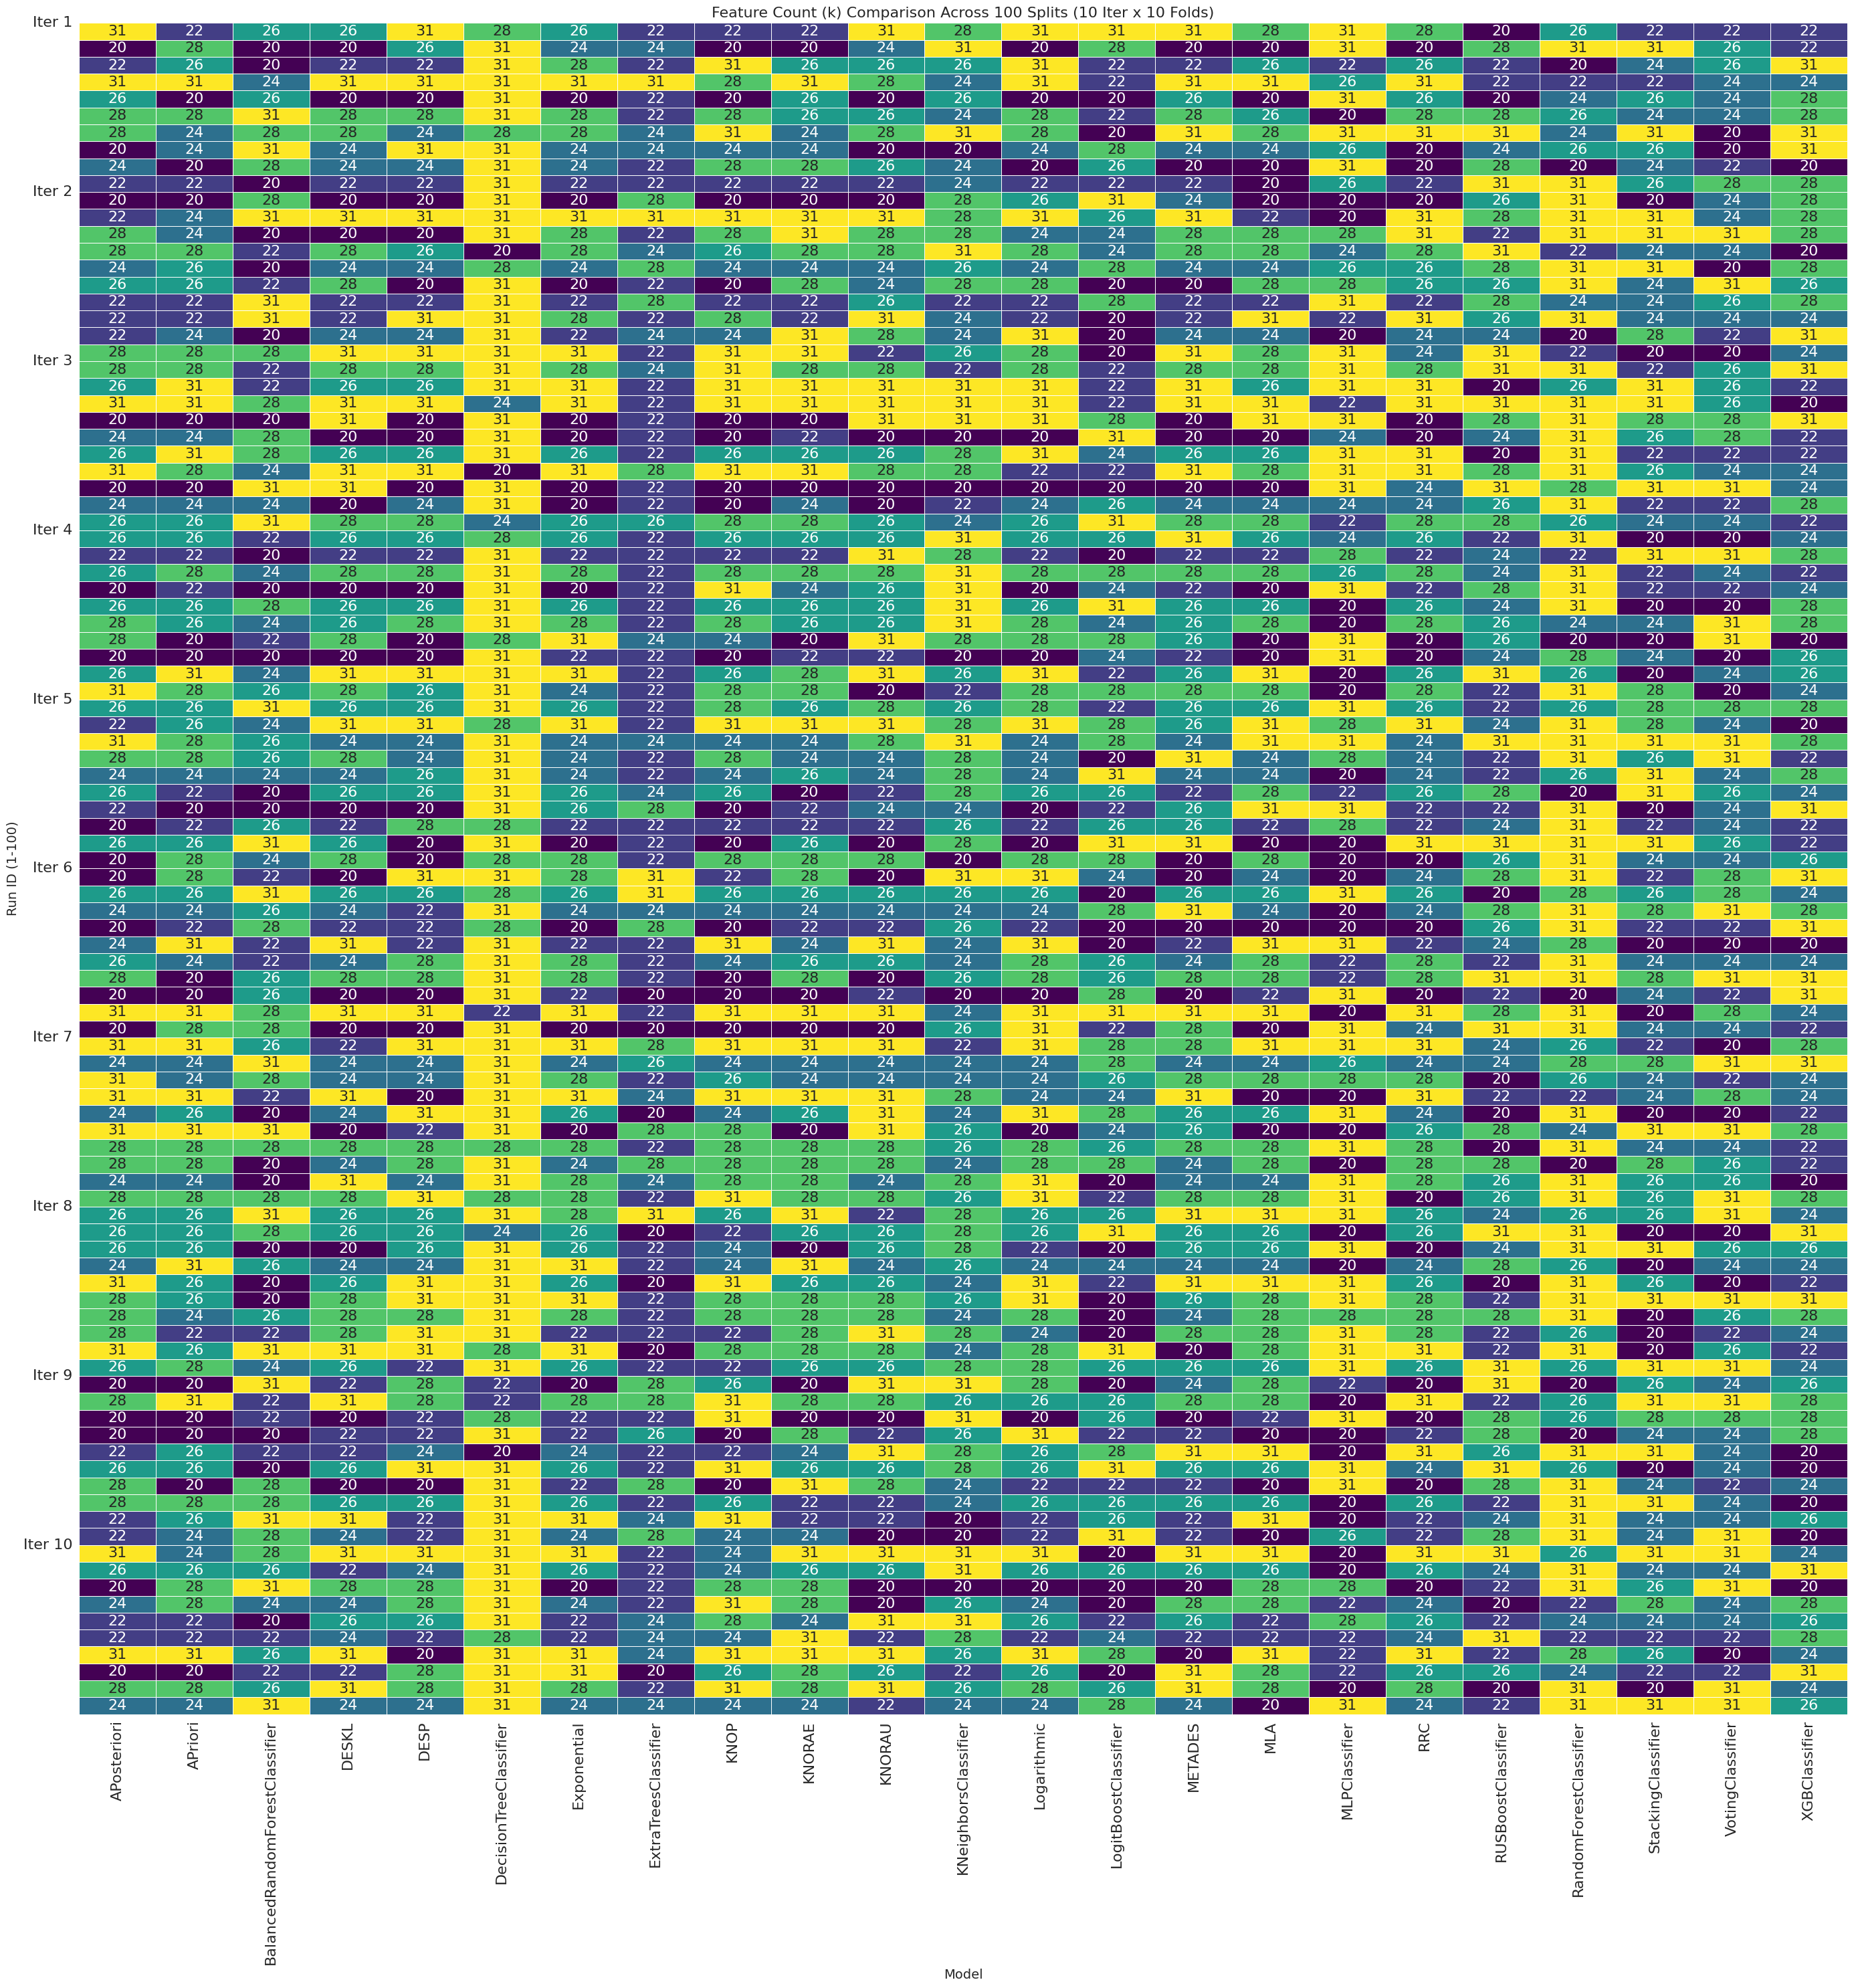

In [12]:
# Pivot the data: Rows = Run ID (1-100), Cols = Model, Values = k
heatmap_data = final_df.pivot(index="run_id", columns="model", values="num_features")

plt.figure(figsize=(28, 30))  # Tall figure to accommodate 100 rows clearly

sns.heatmap(
    heatmap_data,
    annot=True,       # Show the actual number k
    fmt="d",          # Format as integer
    cmap="viridis",   # Color scheme
    cbar=False,
    linewidths=.5,    # Grid lines for readability
)

plt.title("Feature Count (k) Comparison Across 100 Splits (10 Iter x 10 Folds)", fontsize=16)
plt.ylabel("Run ID (1-100)", fontsize=14)
plt.xlabel("Model", fontsize=14)

# Optional: Add tick markers for every 10 runs to see Iteration breaks
plt.yticks(ticks=[i for i in range(0, 100, 10)],
           labels=[f"Iter {i//10 + 1}" for i in range(0, 100, 10)], rotation=0)

plt.tight_layout()
fig_path = FIGURES_FEATURE_SELECTION_EXPERIMENT_DIR / f"num_k_selected_features.png"
plt.savefig(fig_path, dpi=300)
plt.show()

## Feature Stability Ranking

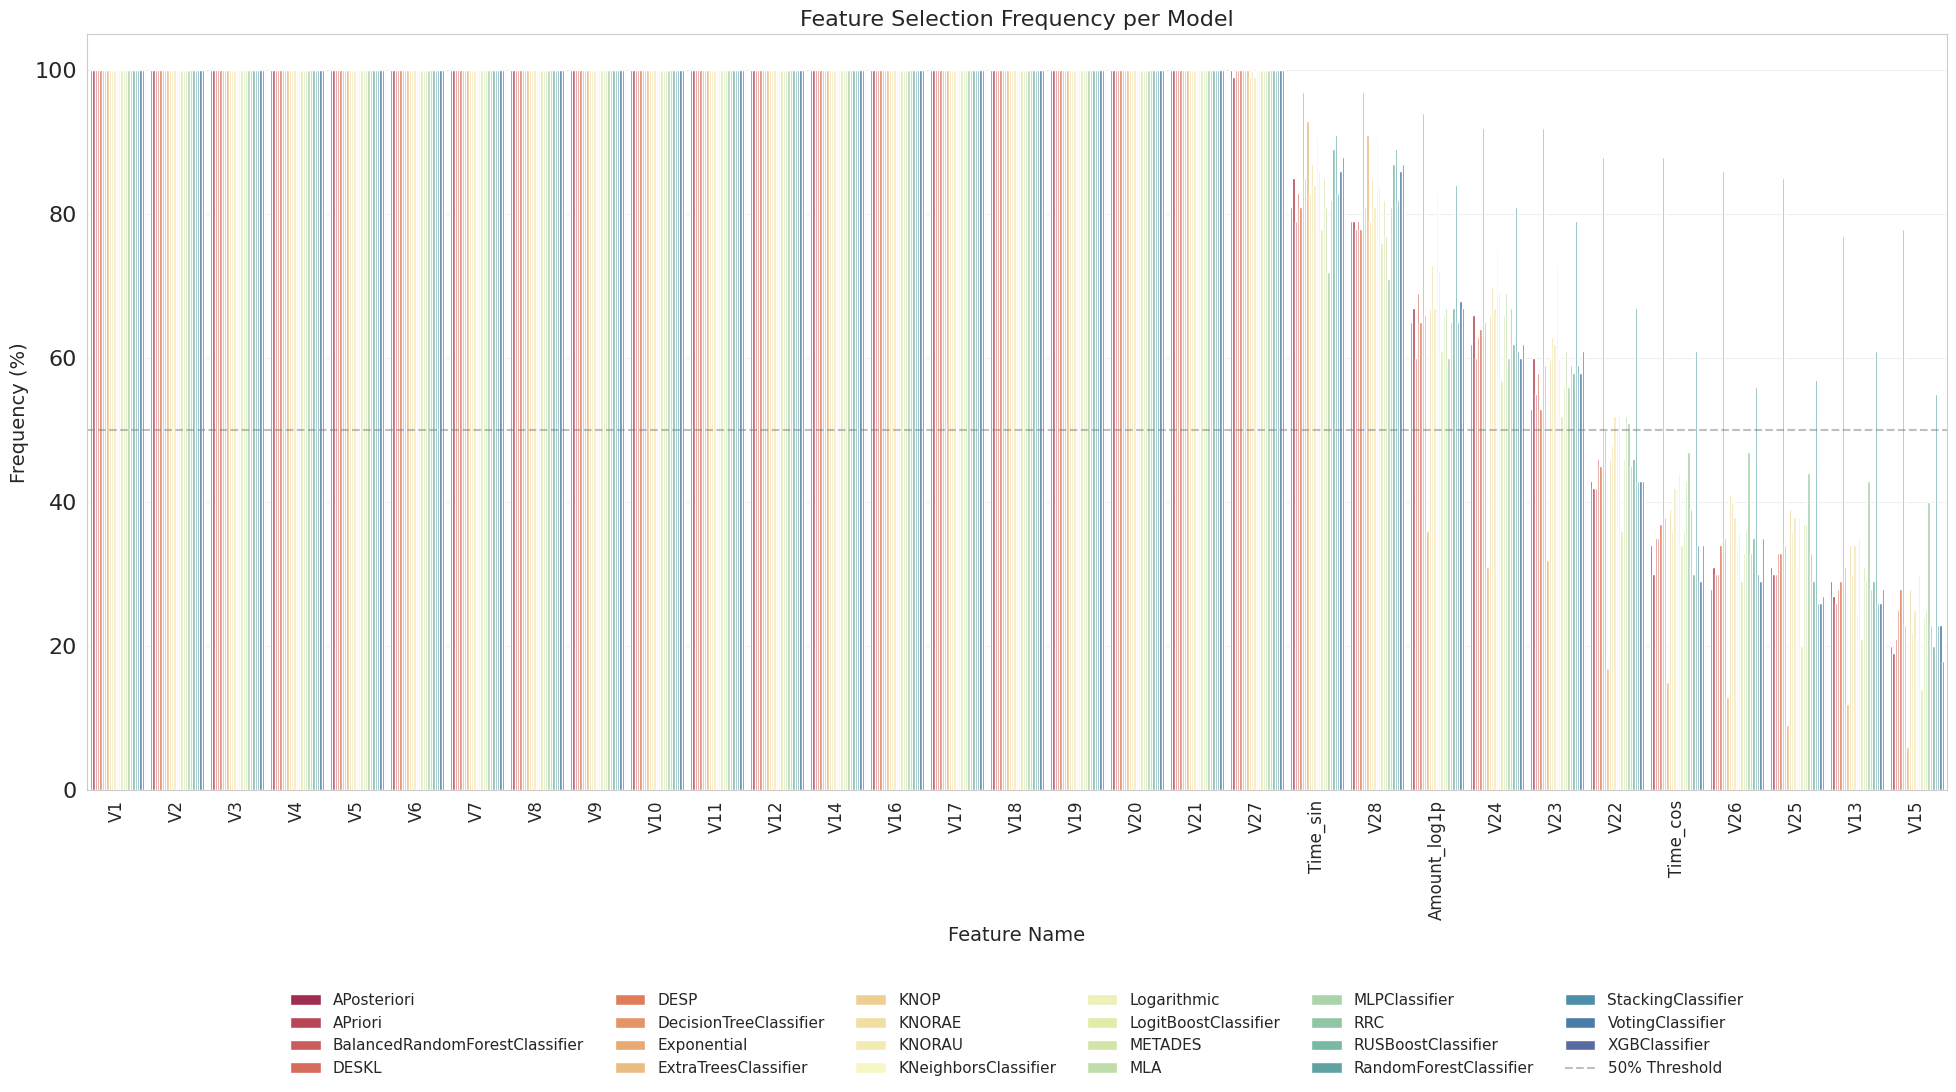

In [13]:
# Explode: One row per feature occurrence
df_exploded = final_df.explode("selected_features_names")

# Calculate Frequencies
# Count occurrences per model
counts = (df_exploded.groupby(["model", "selected_features_names"])
          .size().reset_index(name="count"))

# Calculate percentage (assuming 100 runs per model)
# If run counts differ, use: total_runs = df.groupby("model").size()
counts["frequency"] = (counts["count"] / 100) * 100

# Define Sort Order (Most popular features first)
order = df_exploded["selected_features_names"].value_counts().index

# Plot
fig, ax = plt.subplots(figsize=(24, 12))

sns.barplot(
    data=counts,
    x="selected_features_names",  # Features on X
    y="frequency",                # Frequency on Y
    hue="model",
    order=order,
    palette="Spectral",
    width=0.9,
    ax=ax
)

# Rotate X-axis labels so they don't overlap
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=90, ha="center", fontsize=12)

# Correct Labels and Grid
ax.set_title("Feature Selection Frequency per Model", fontsize=16)
ax.set_ylabel("Frequency (%)", fontsize=14)
ax.set_xlabel("Feature Name", fontsize=14)

# Horizontal Threshold Line (since frequency is now on Y)
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5, label="50% Threshold")
ax.grid(axis="y", alpha=0.3)  # Grid lines should now be horizontal

# Legend at the Bottom
ax.legend(
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25), # Pushed down further to clear rotated labels
    ncol=6,                      # Increase columns to fit in fewer rows
    frameon=False,
    fontsize=11
)

plt.subplots_adjust(bottom=0.25) # Add significant bottom margin for labels + legend
fig_path = FIGURES_FEATURE_SELECTION_EXPERIMENT_DIR / "feature_selection_frequency.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

### Heatmap of features per model and iteration_fold

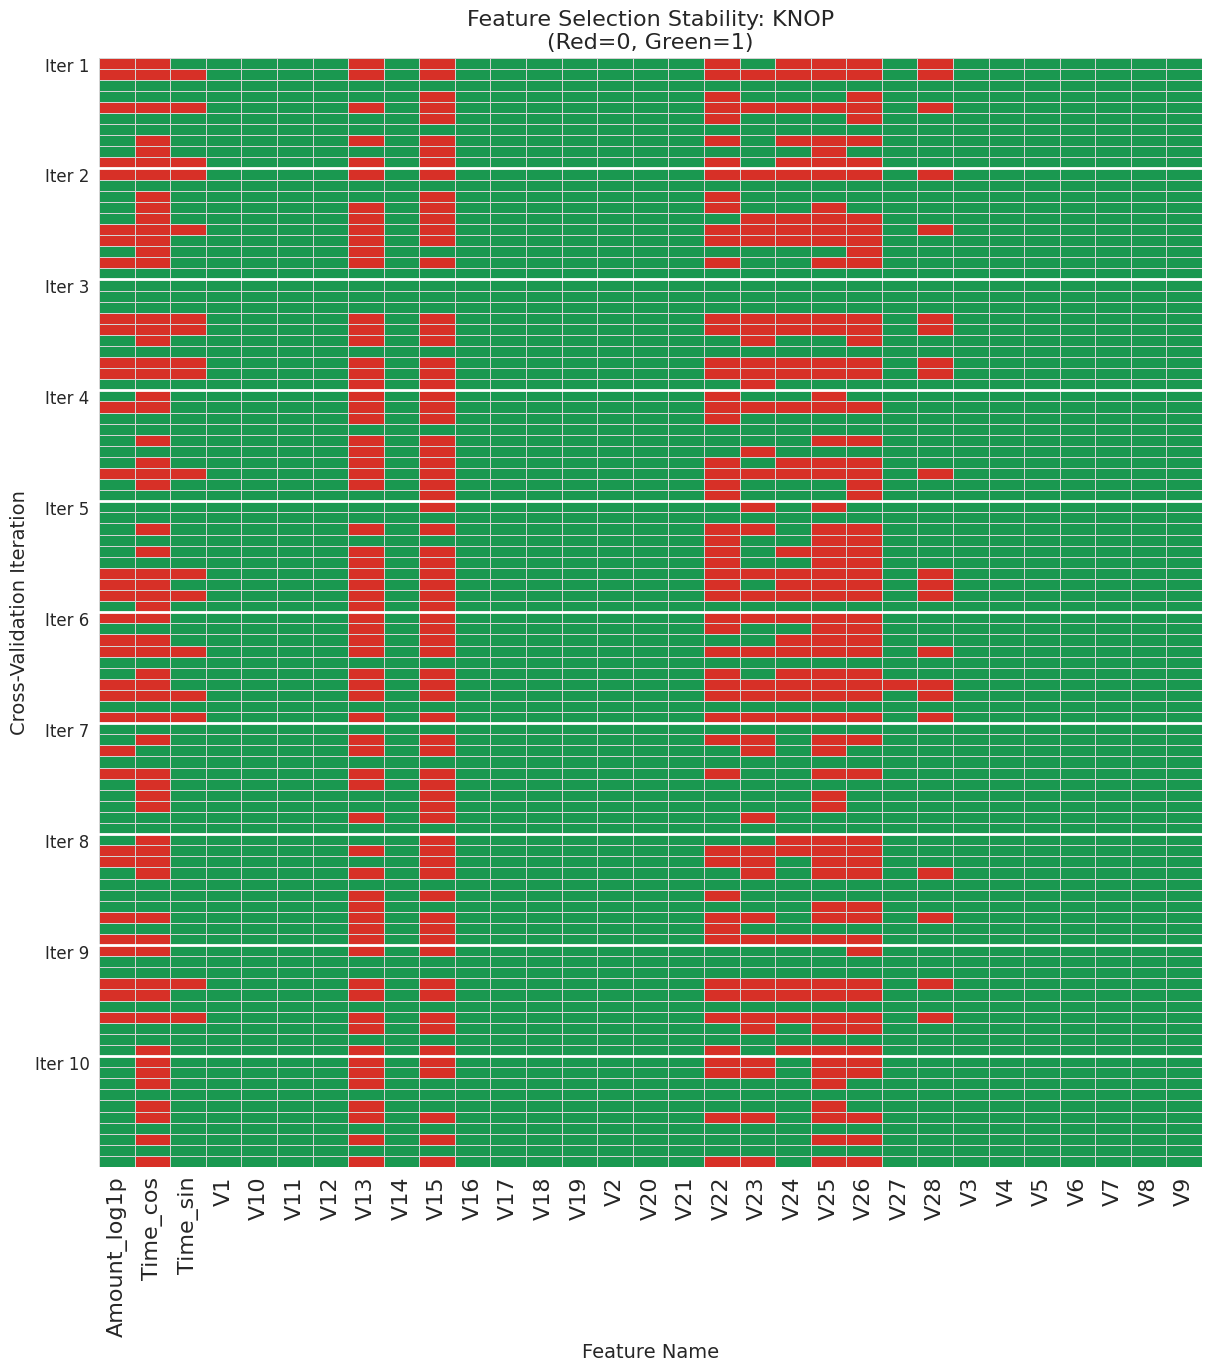

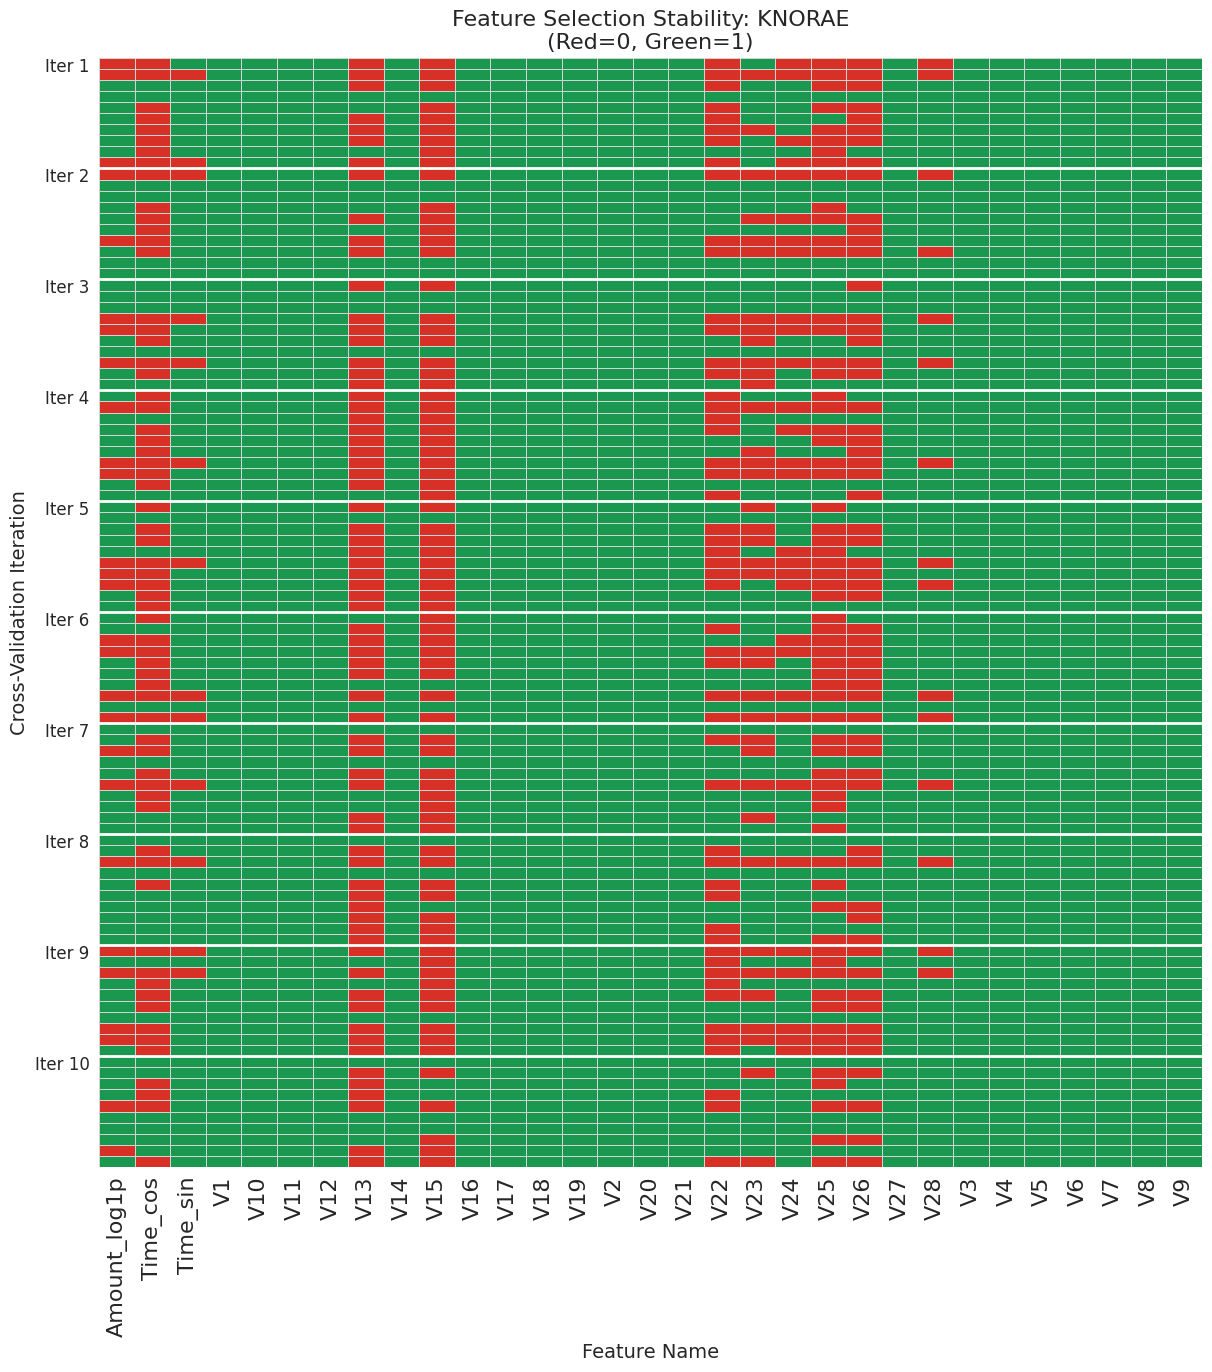

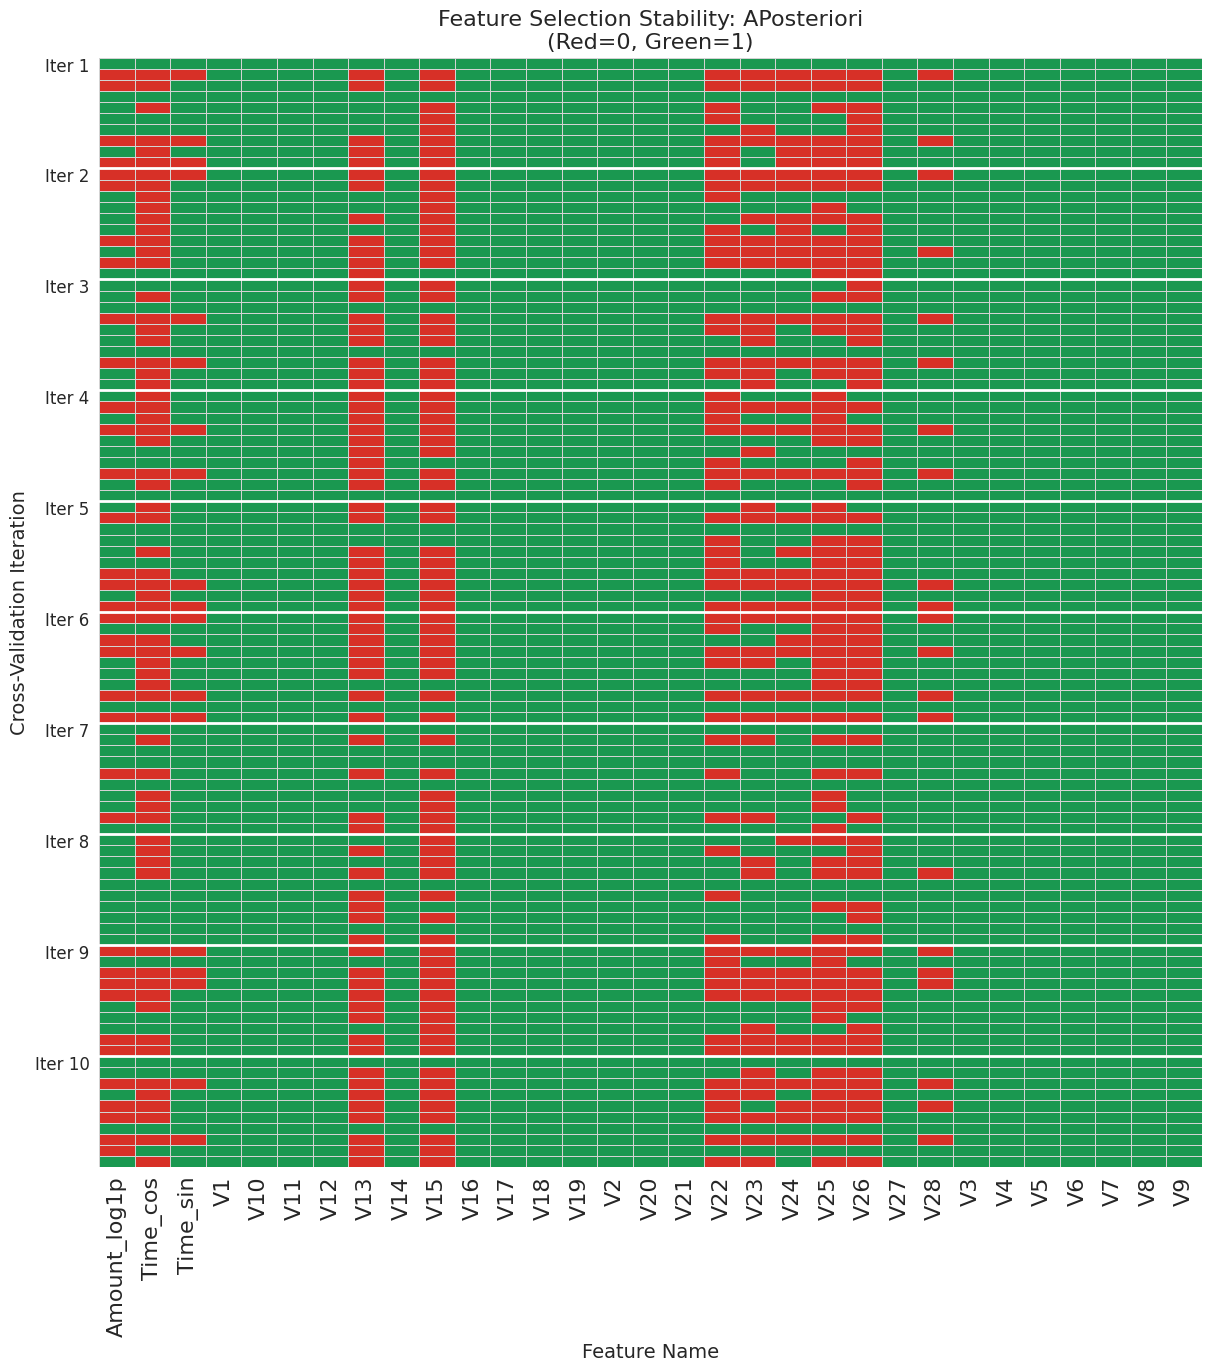

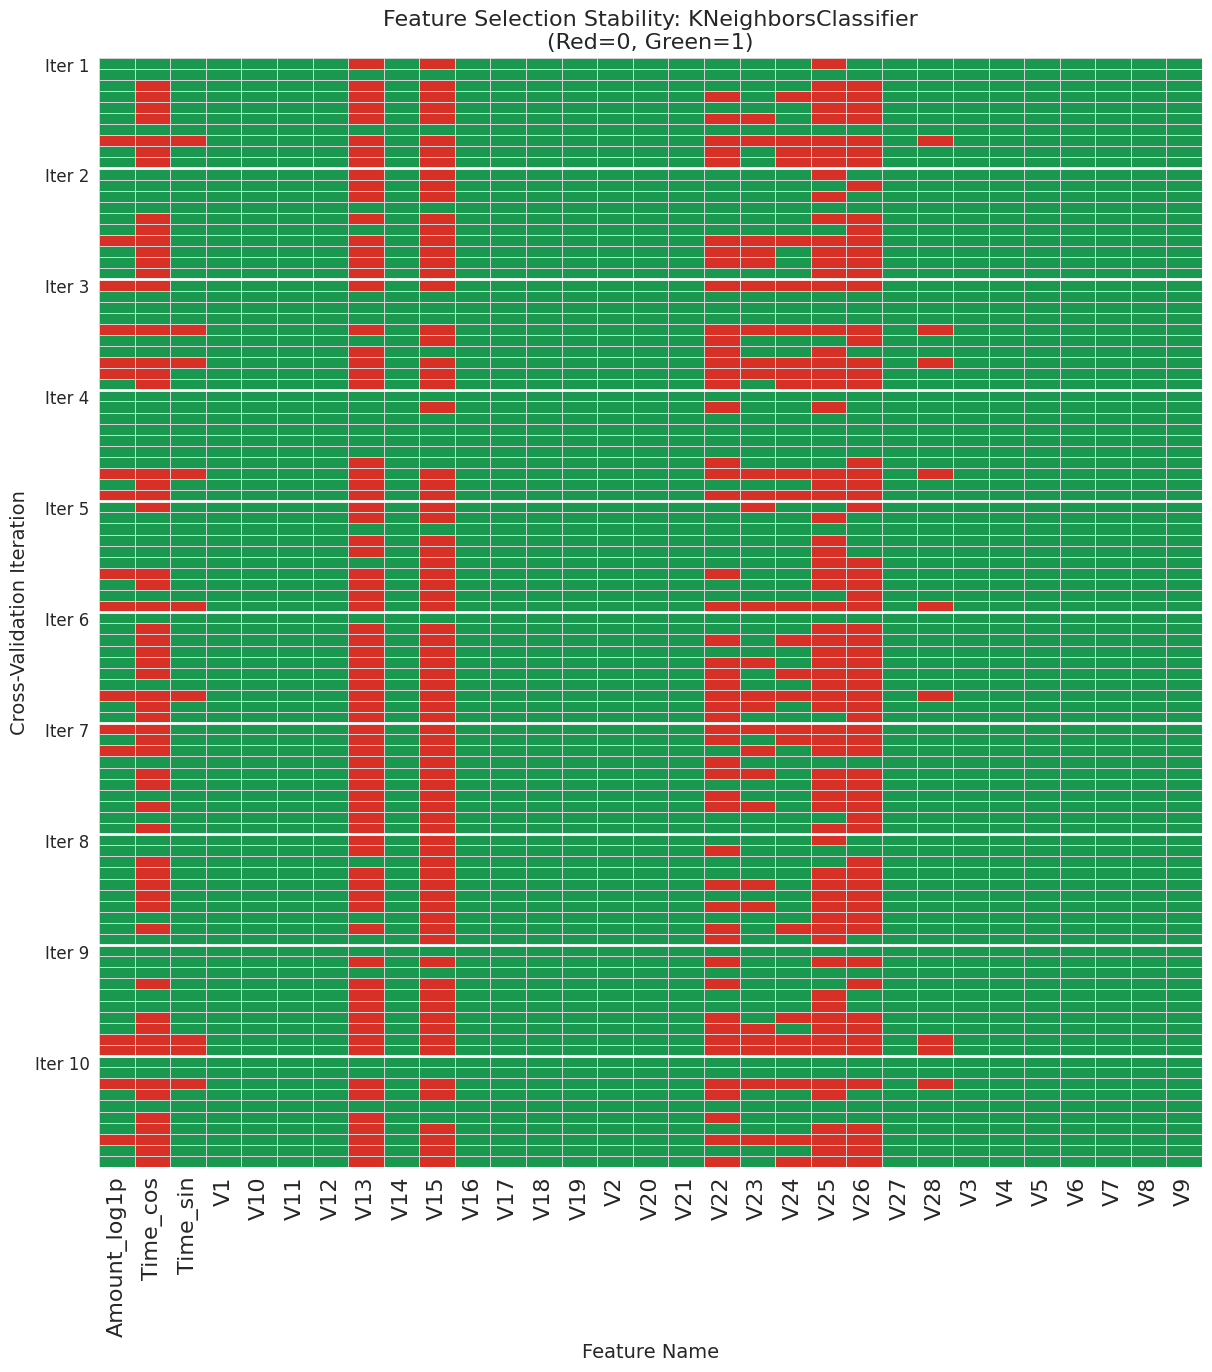

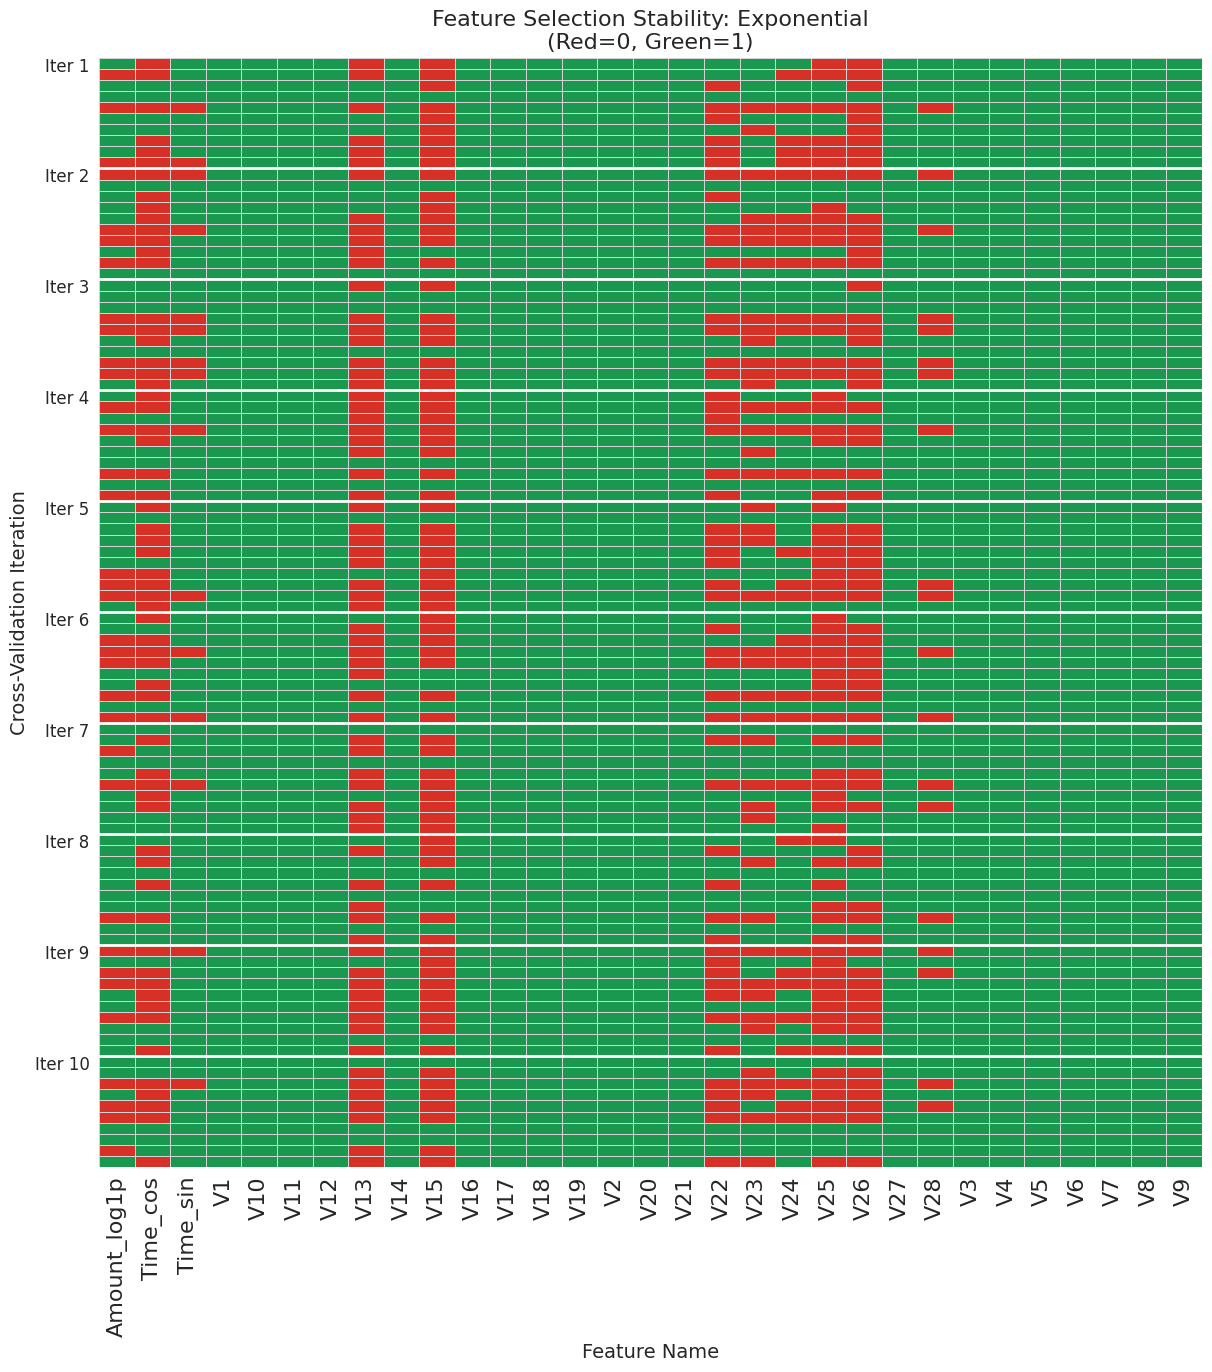

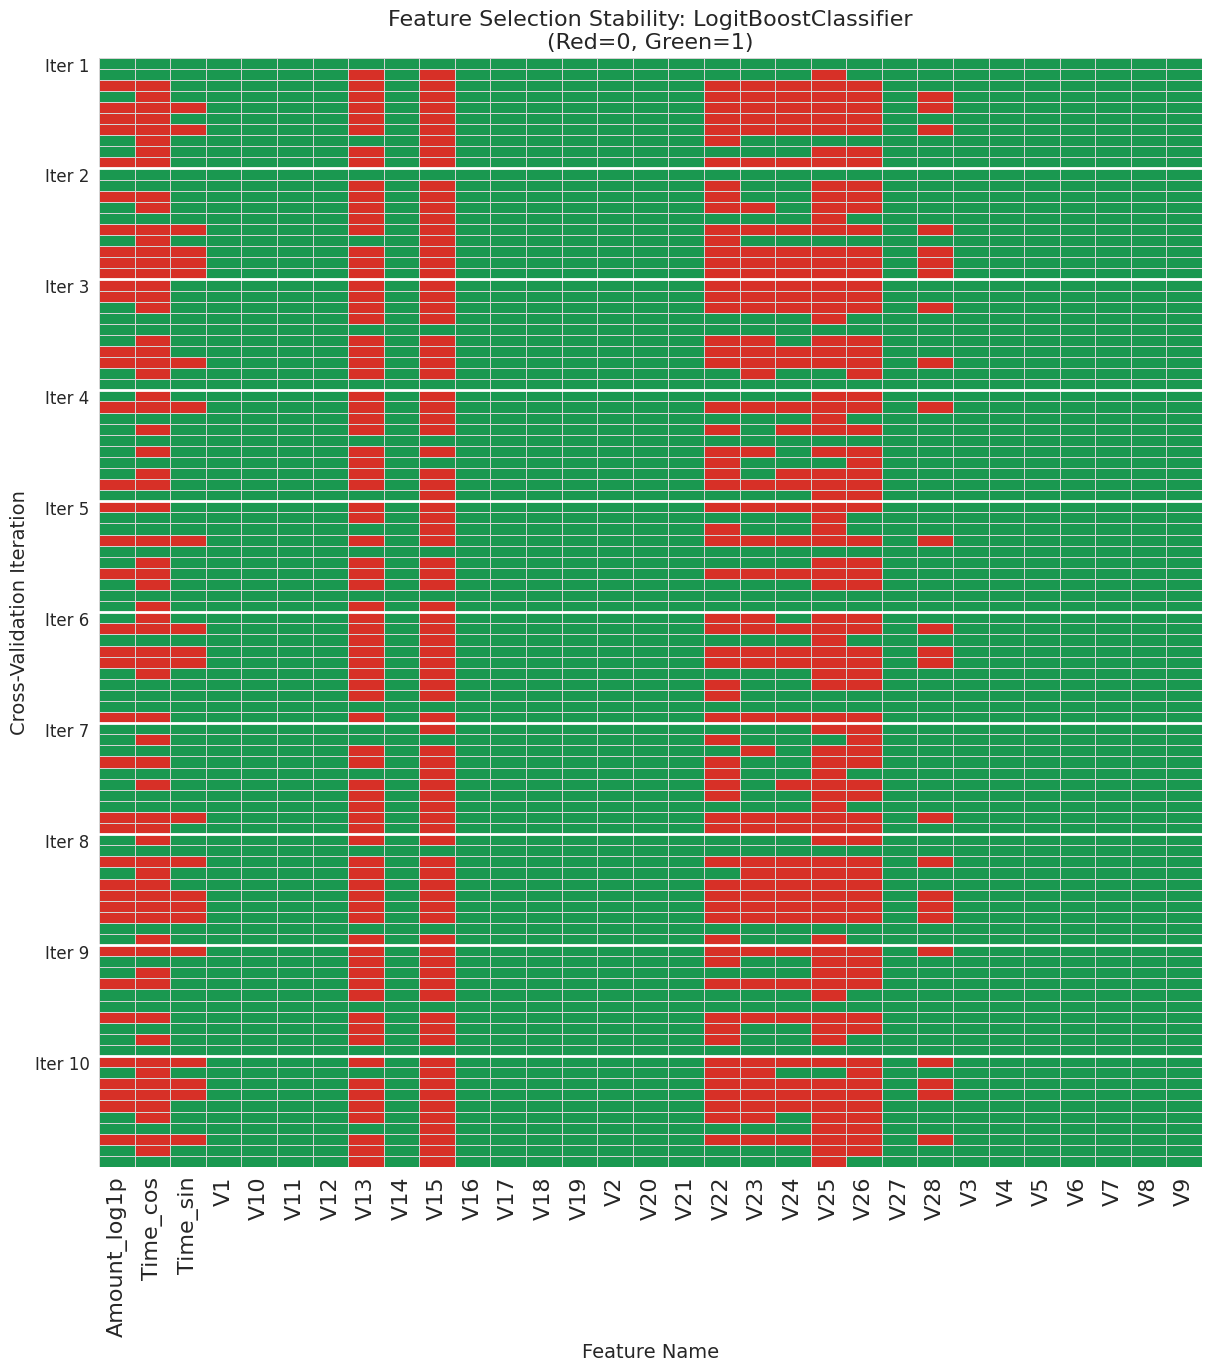

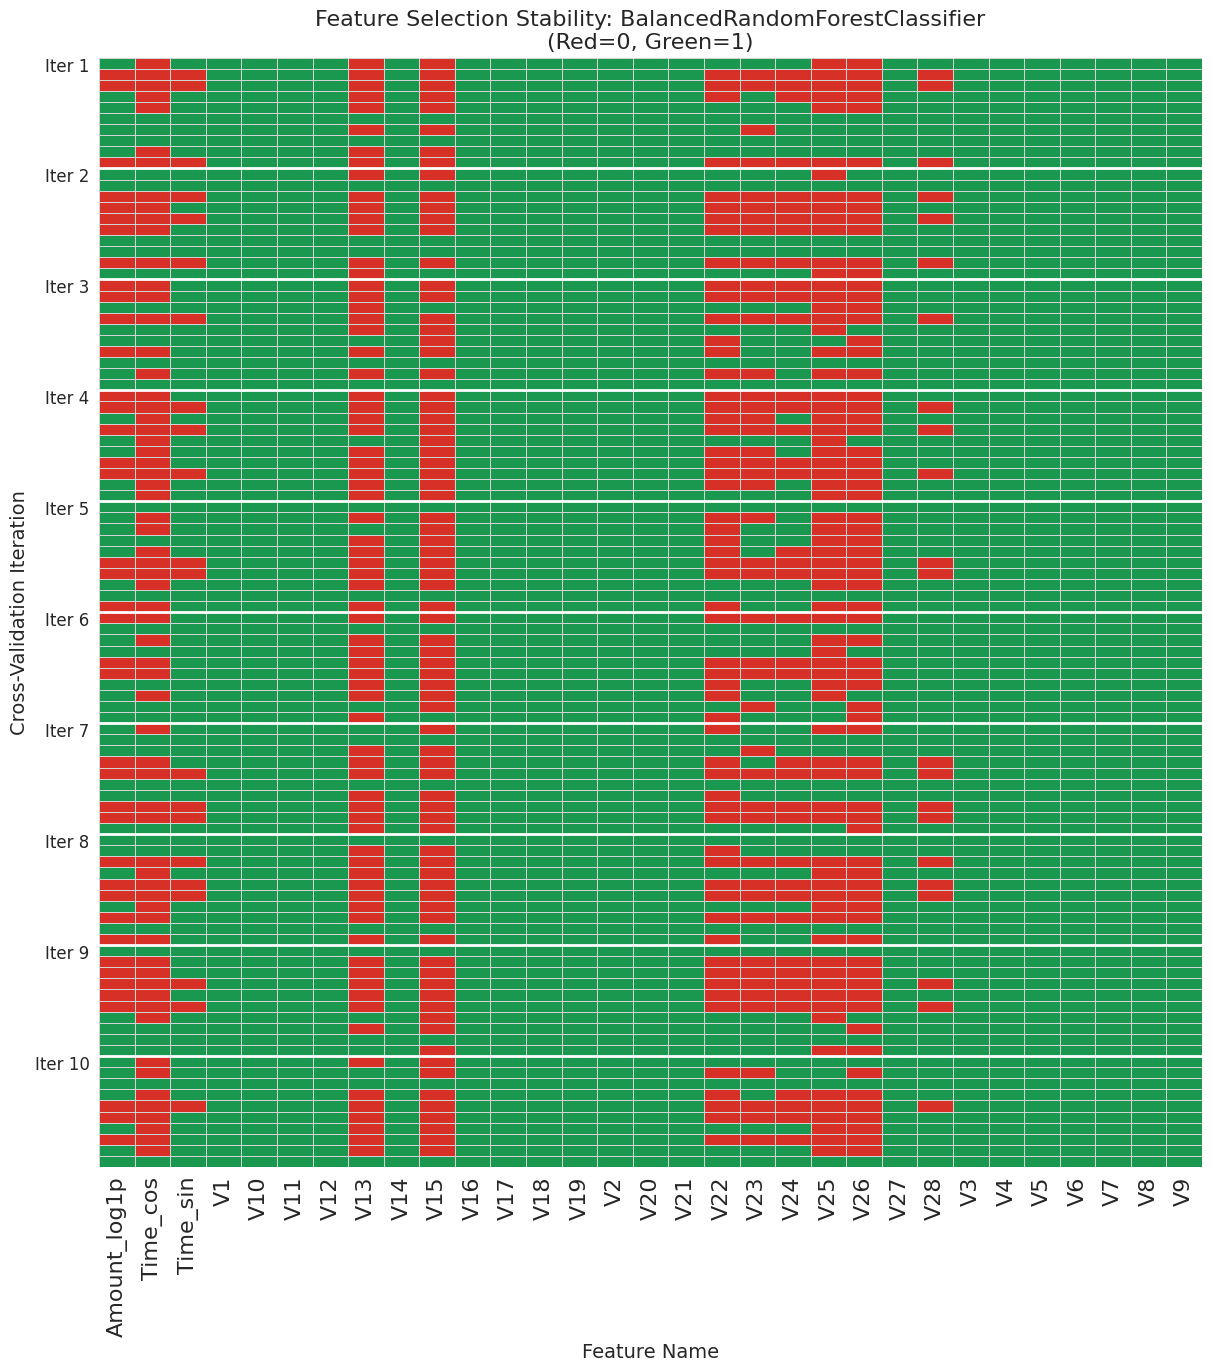

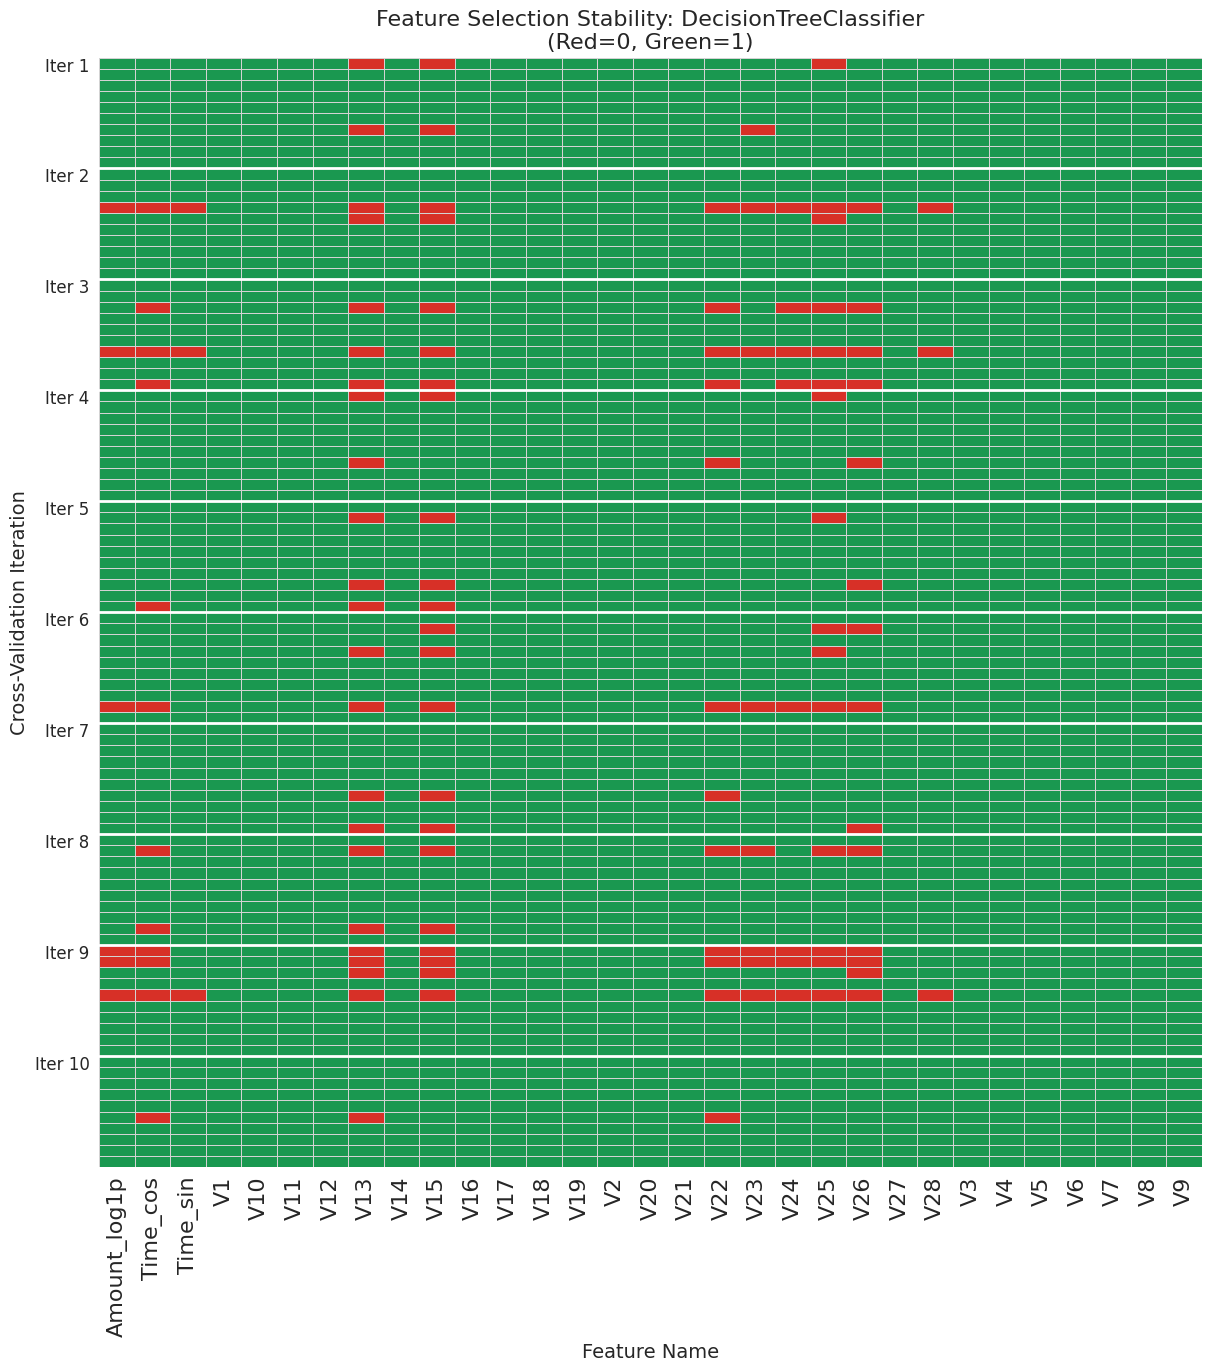

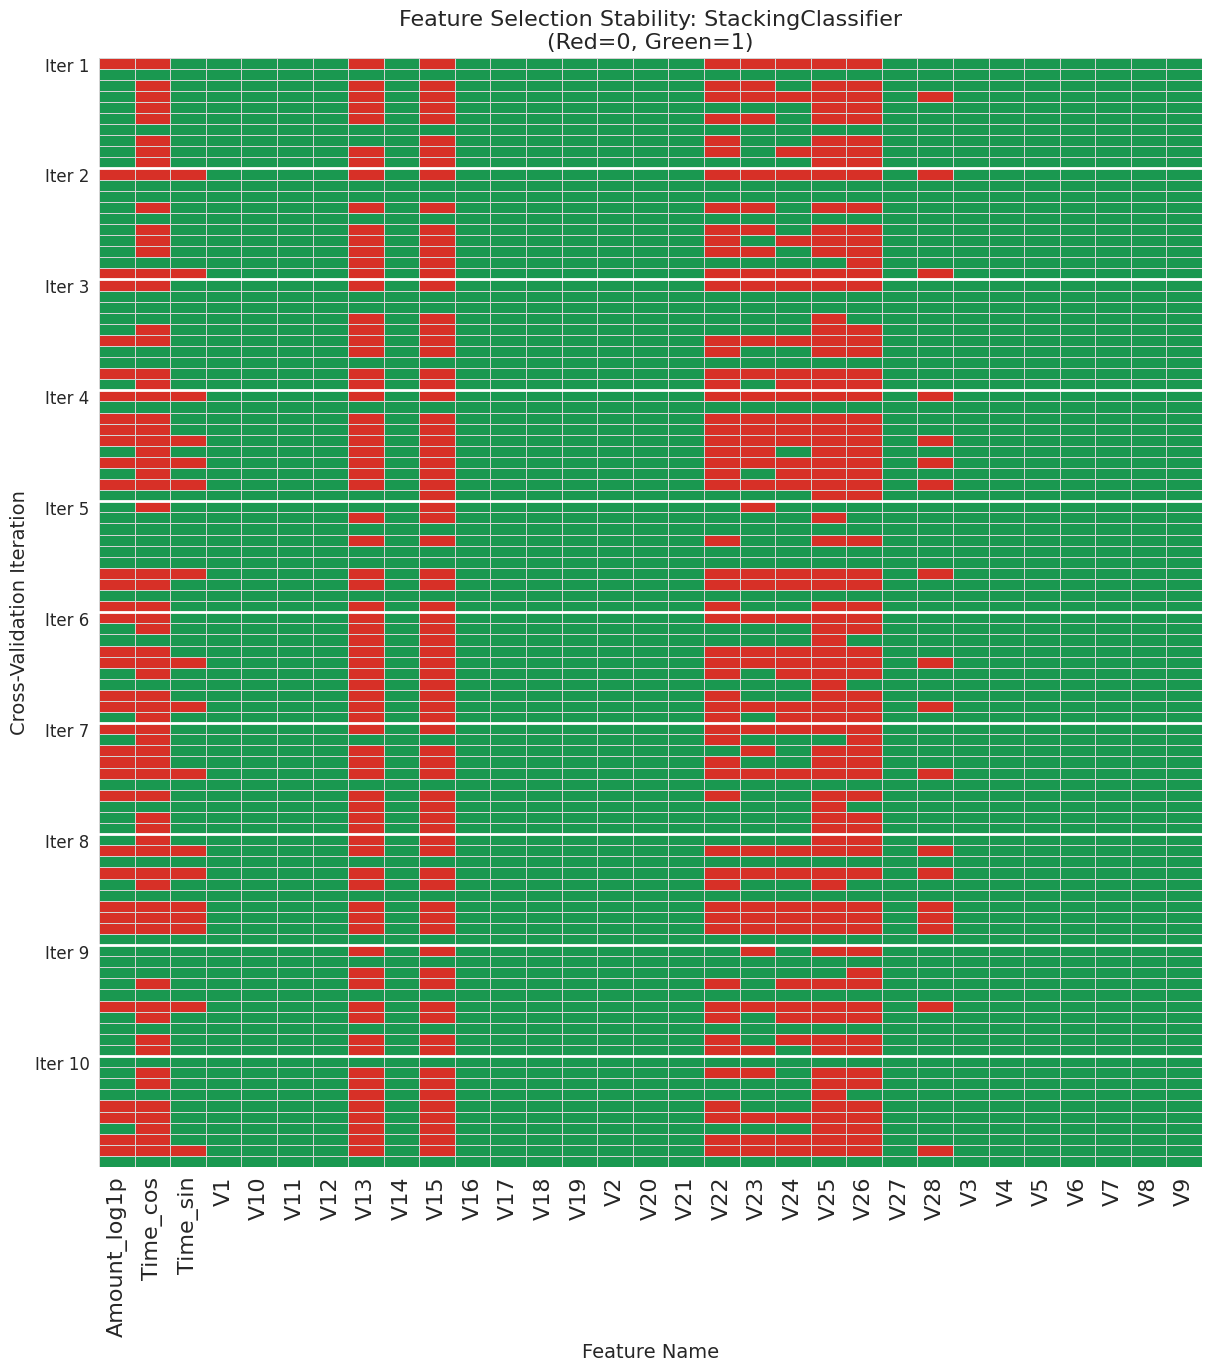

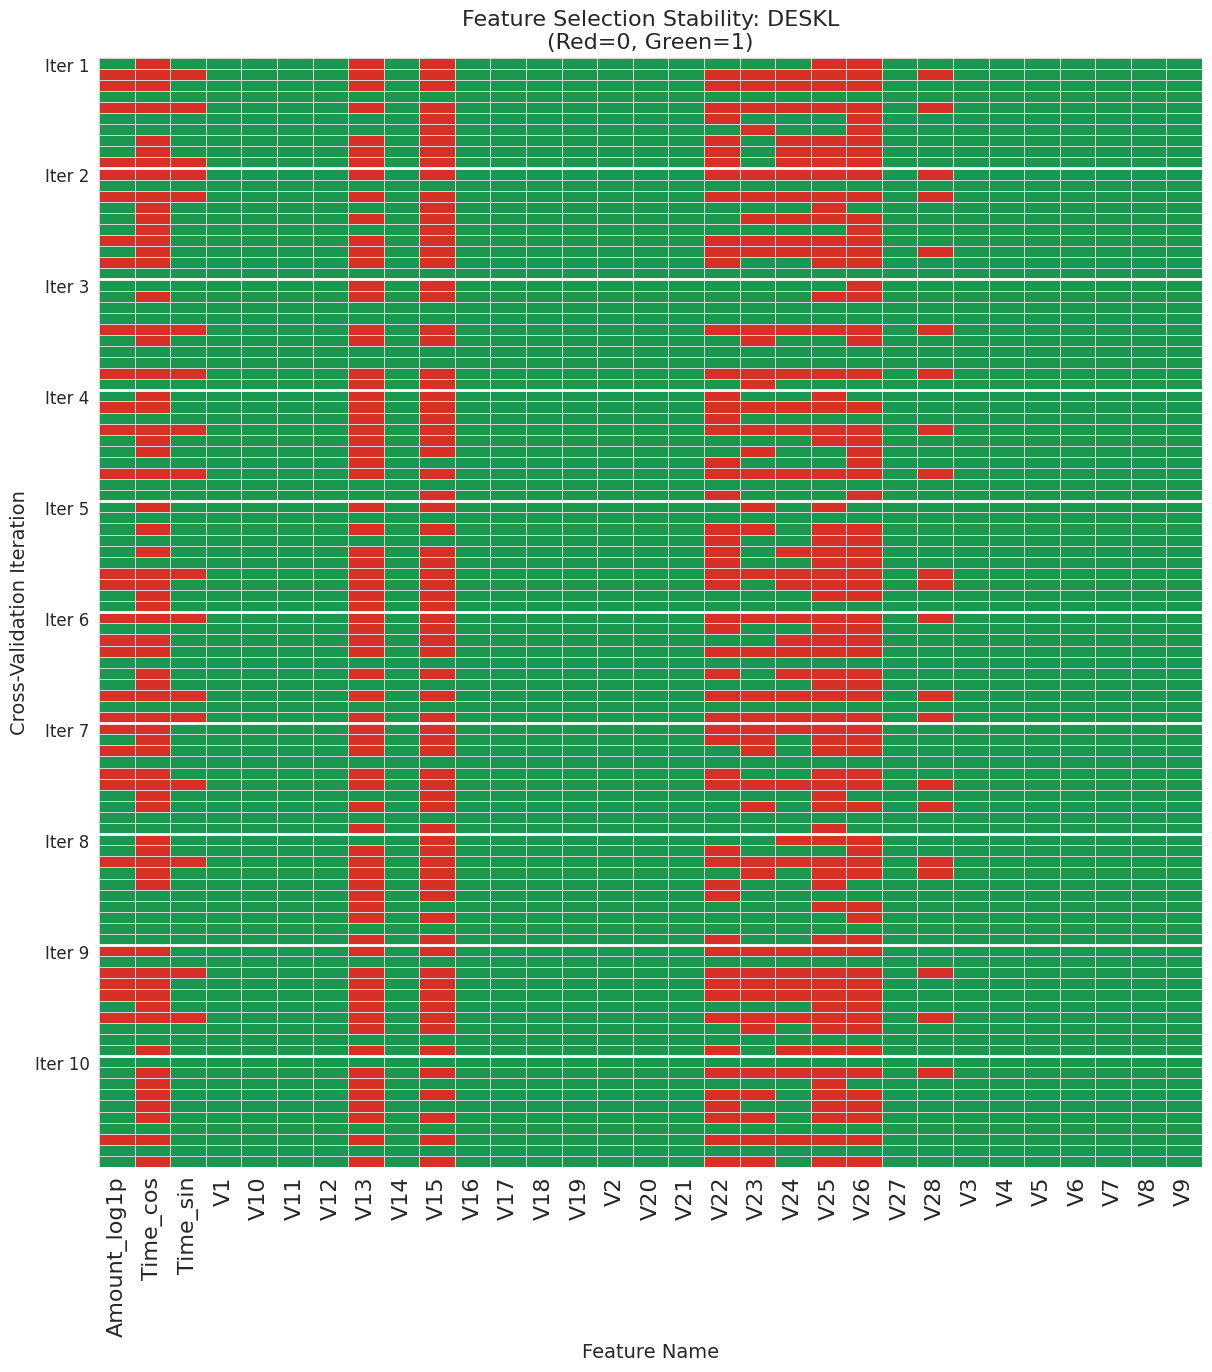

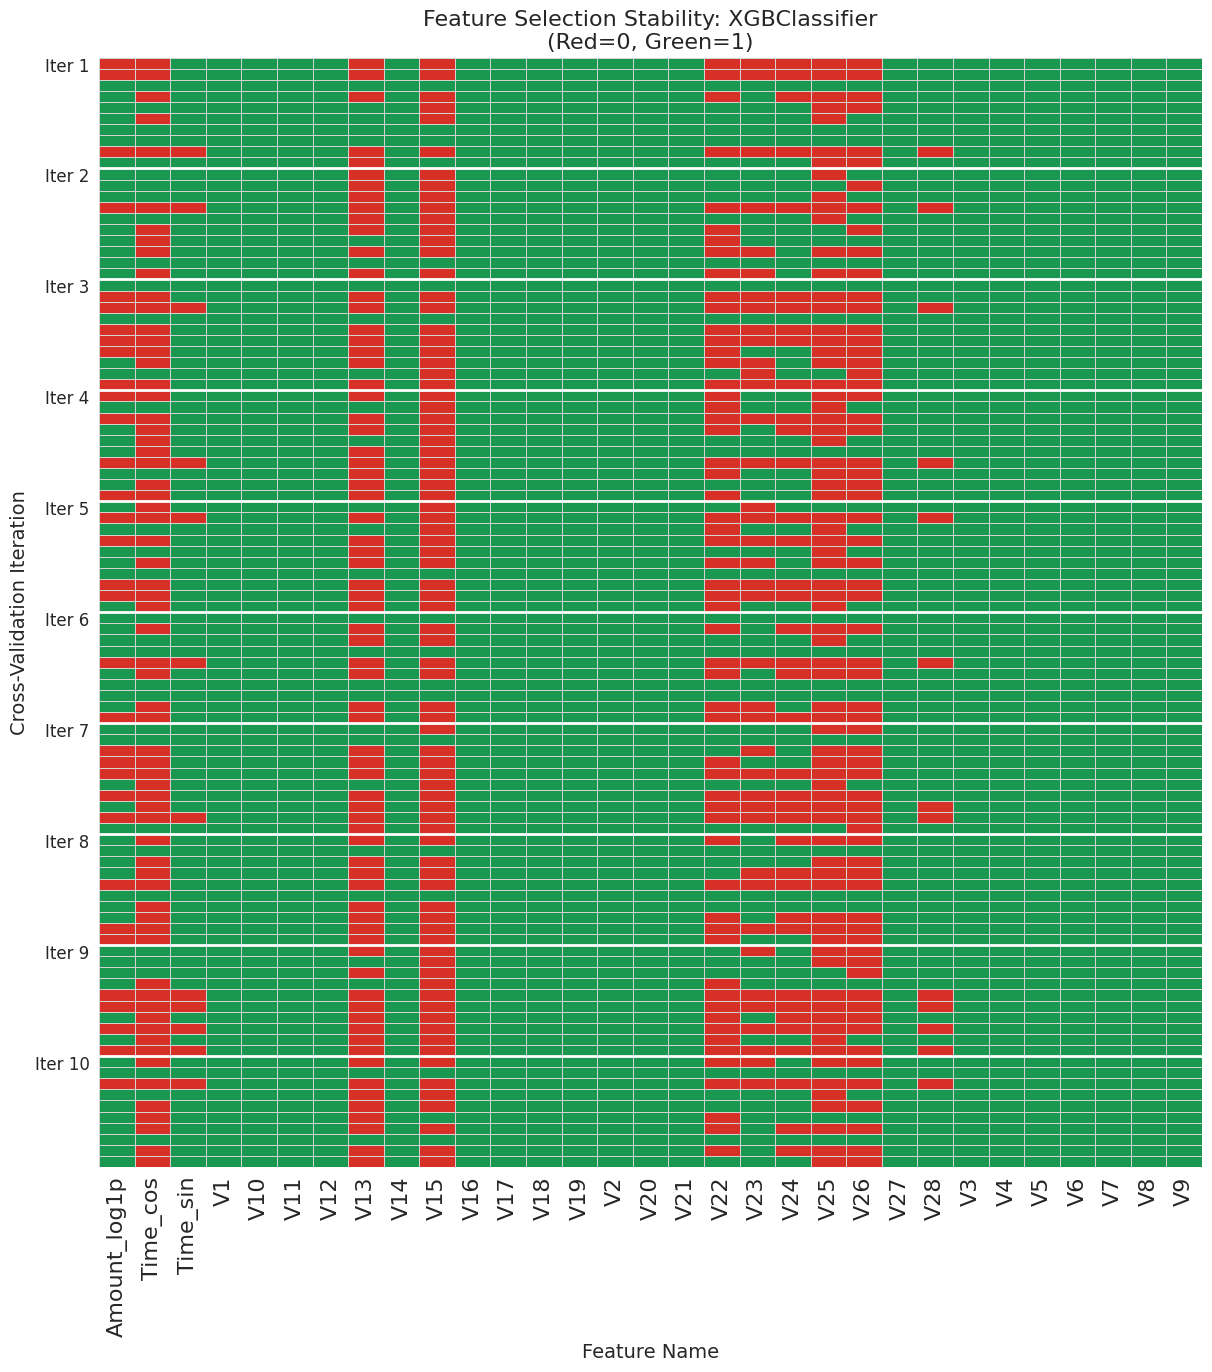

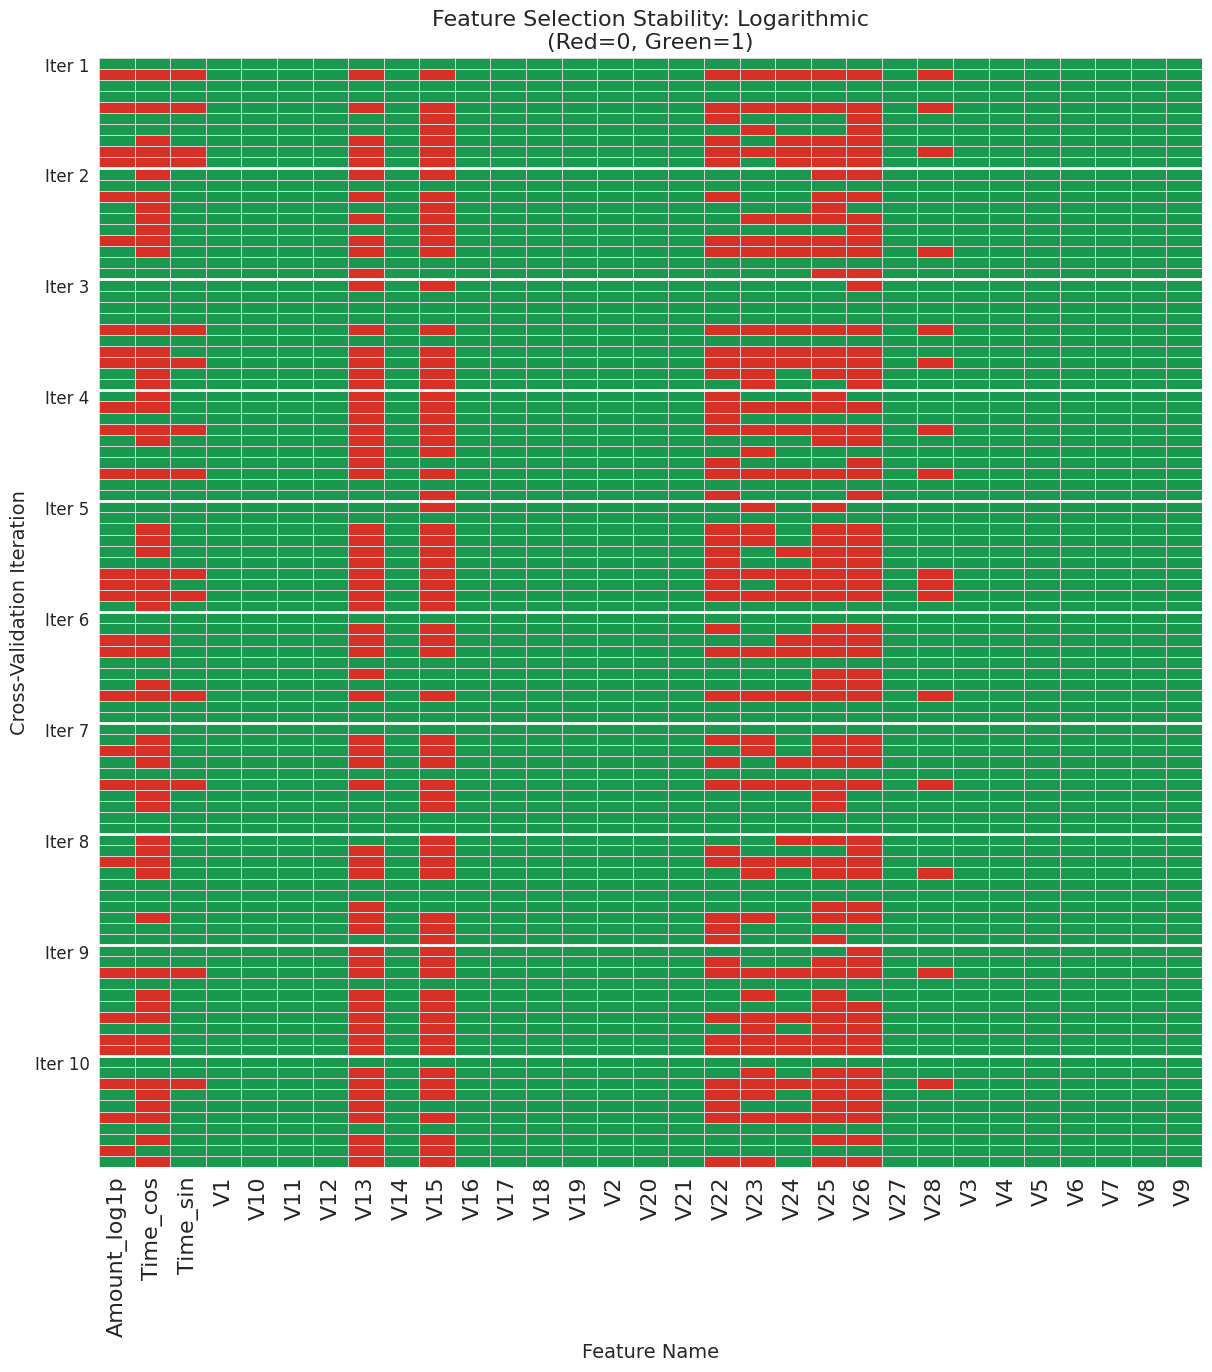

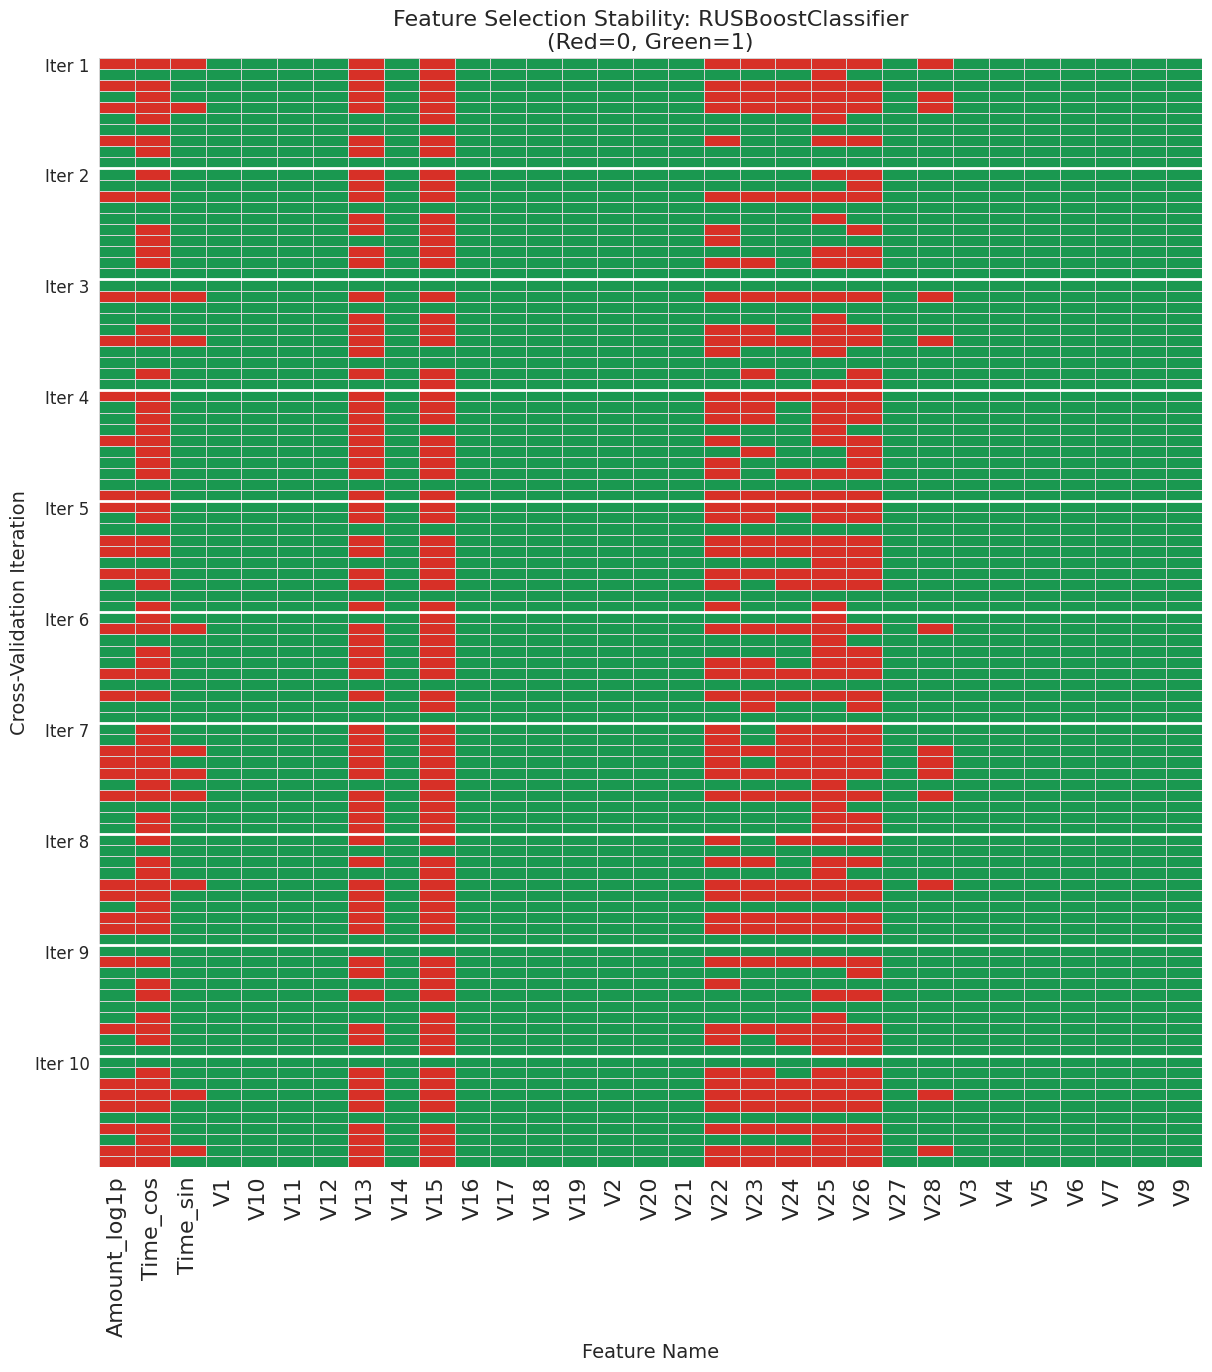

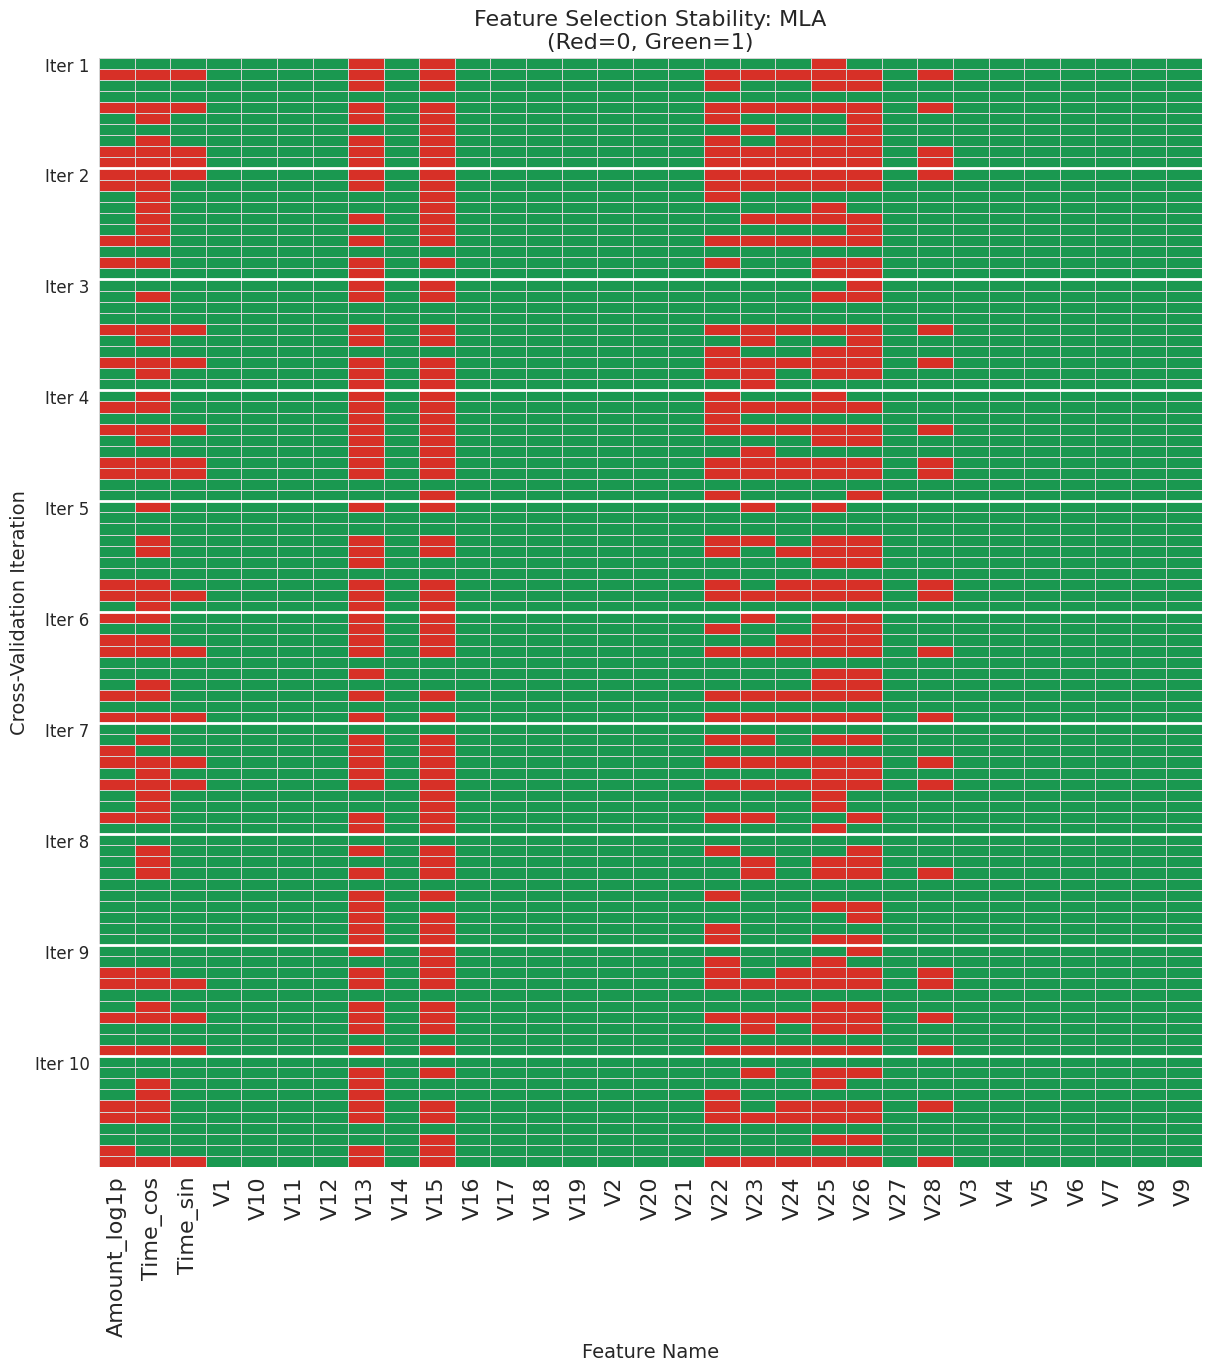

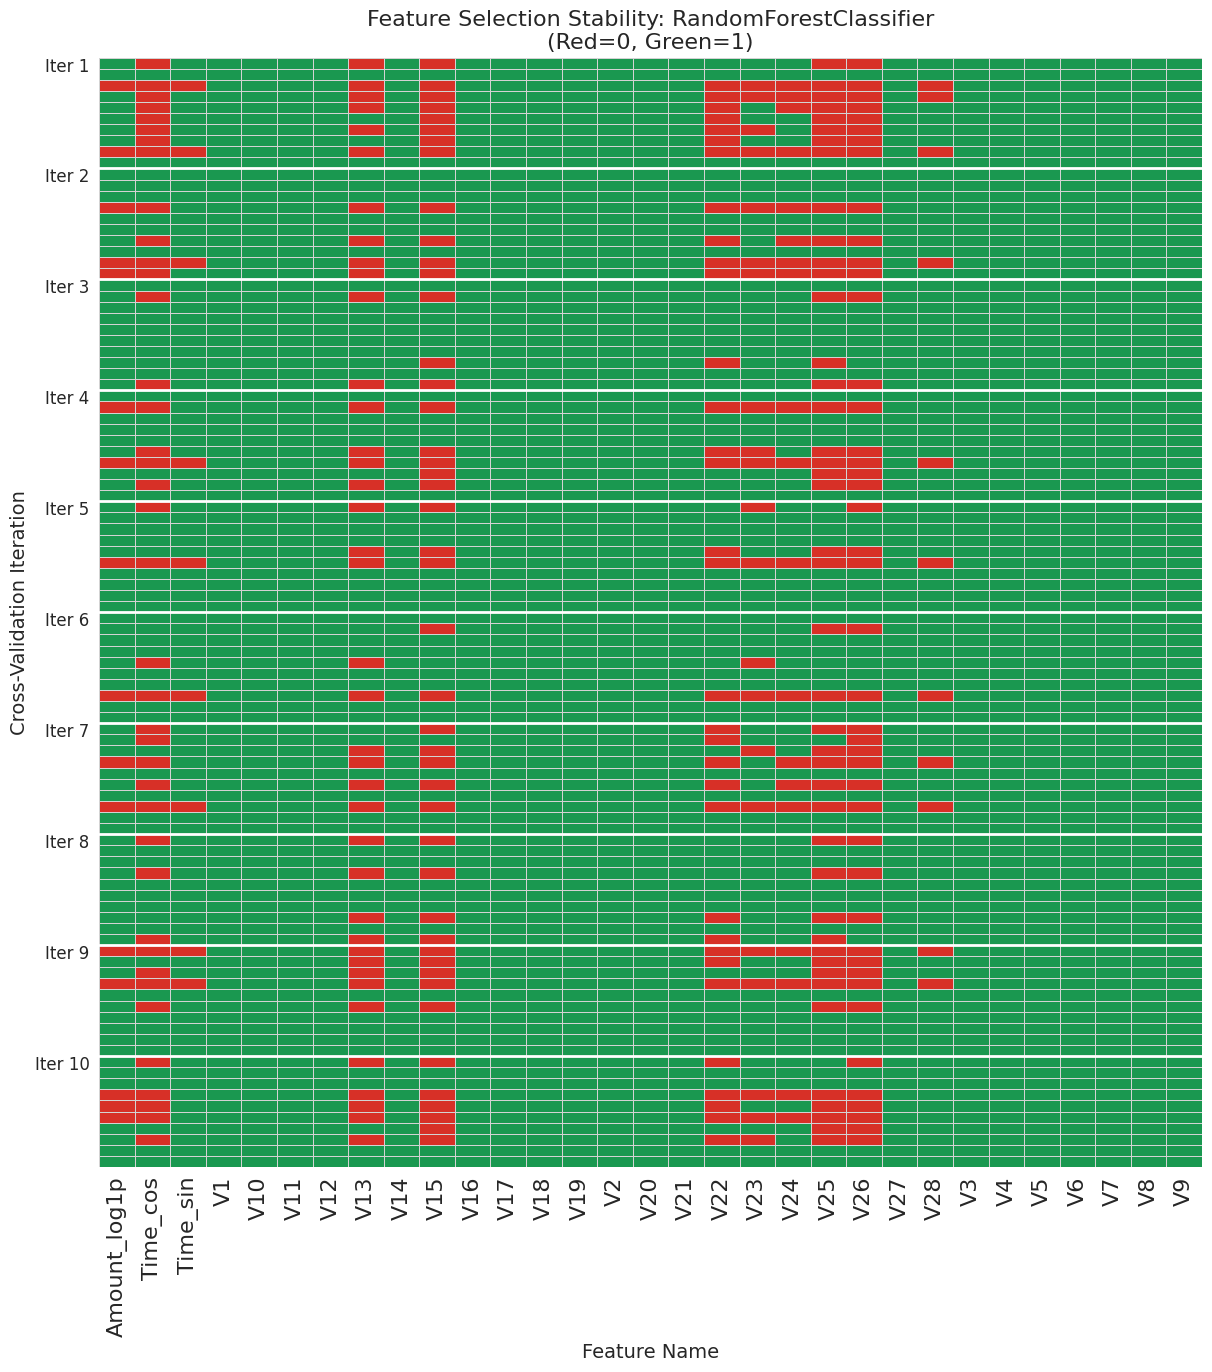

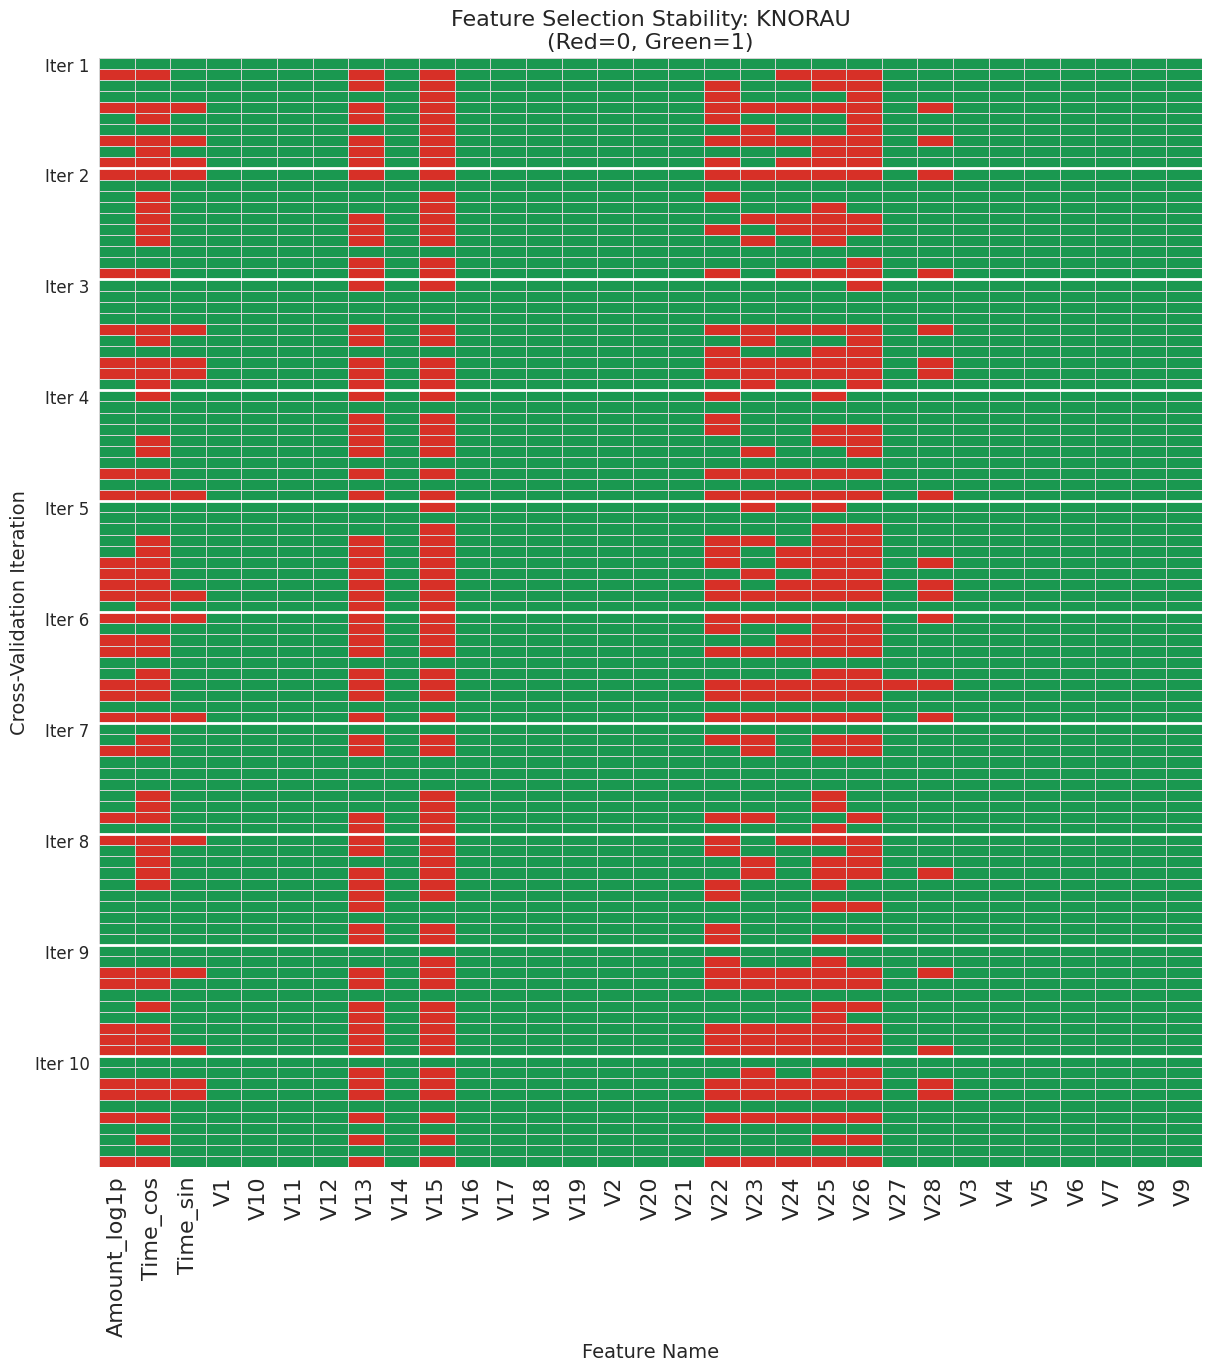

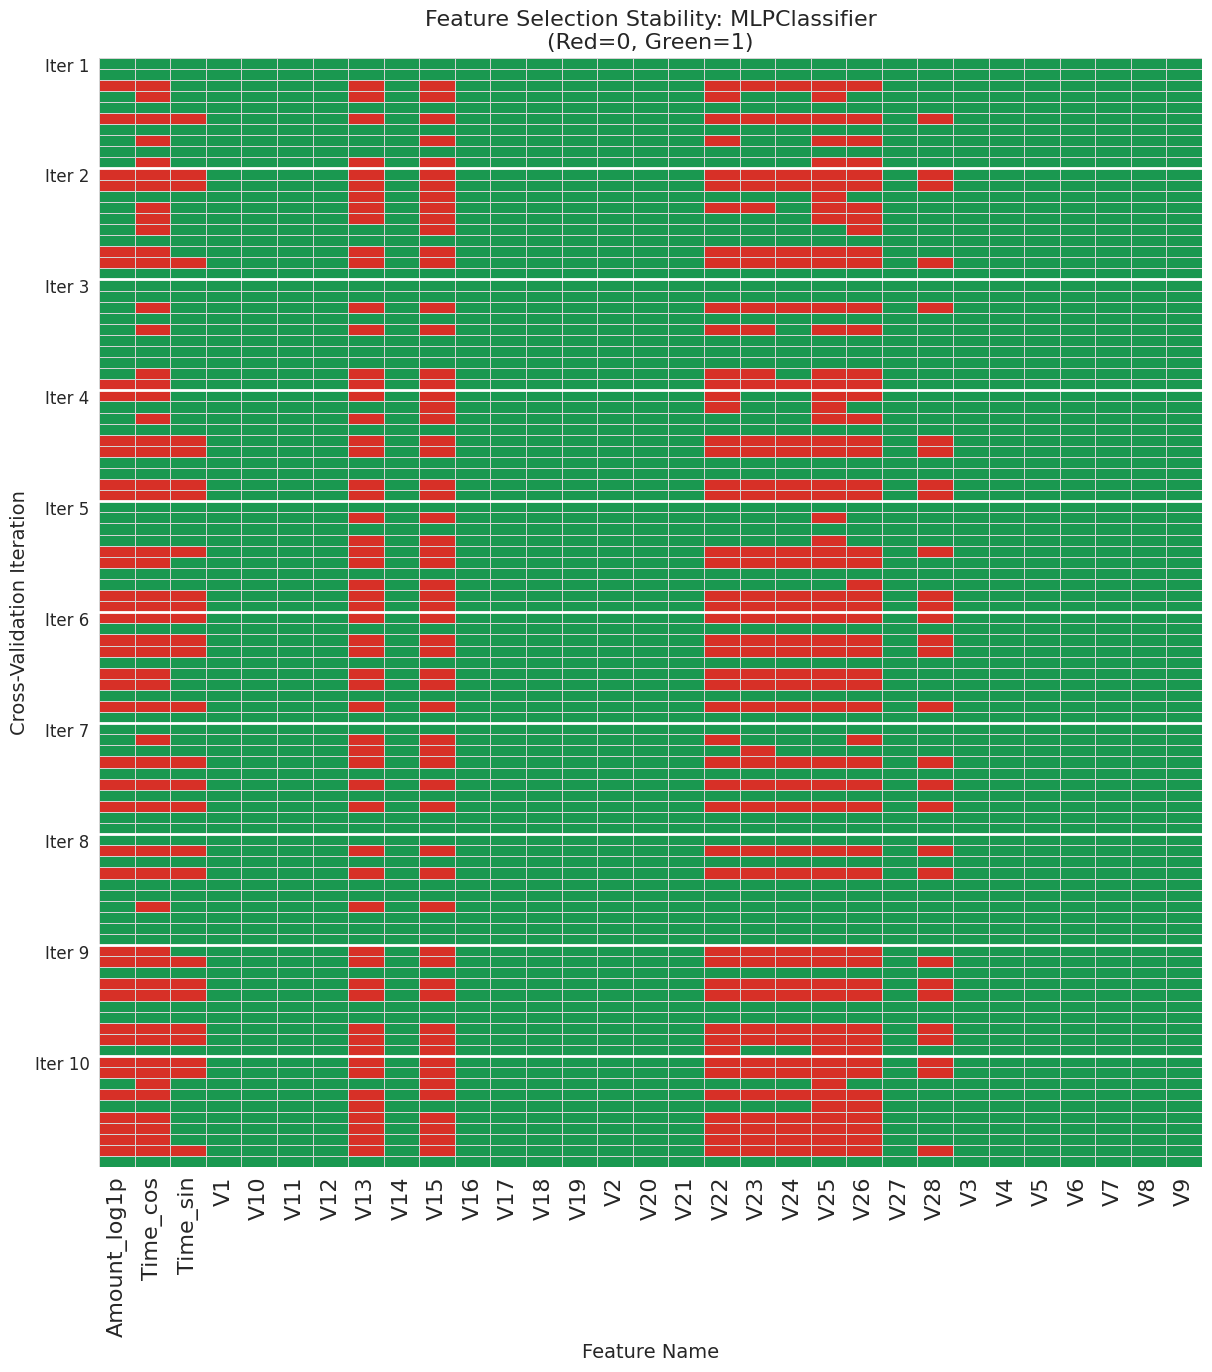

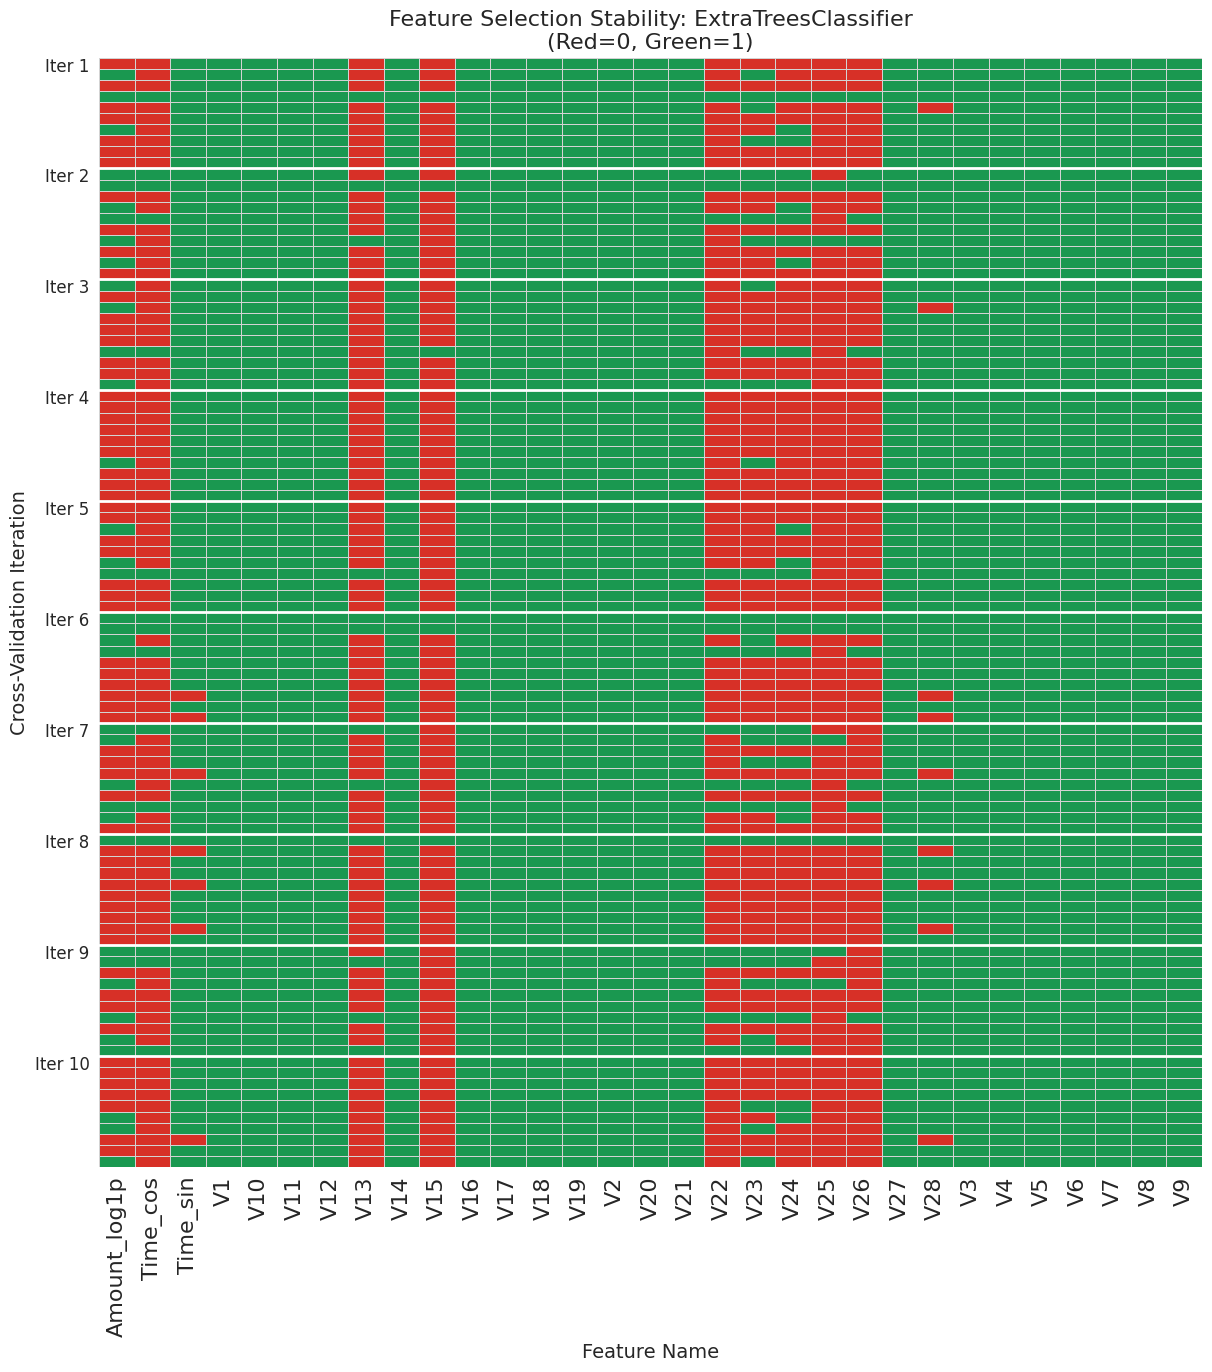

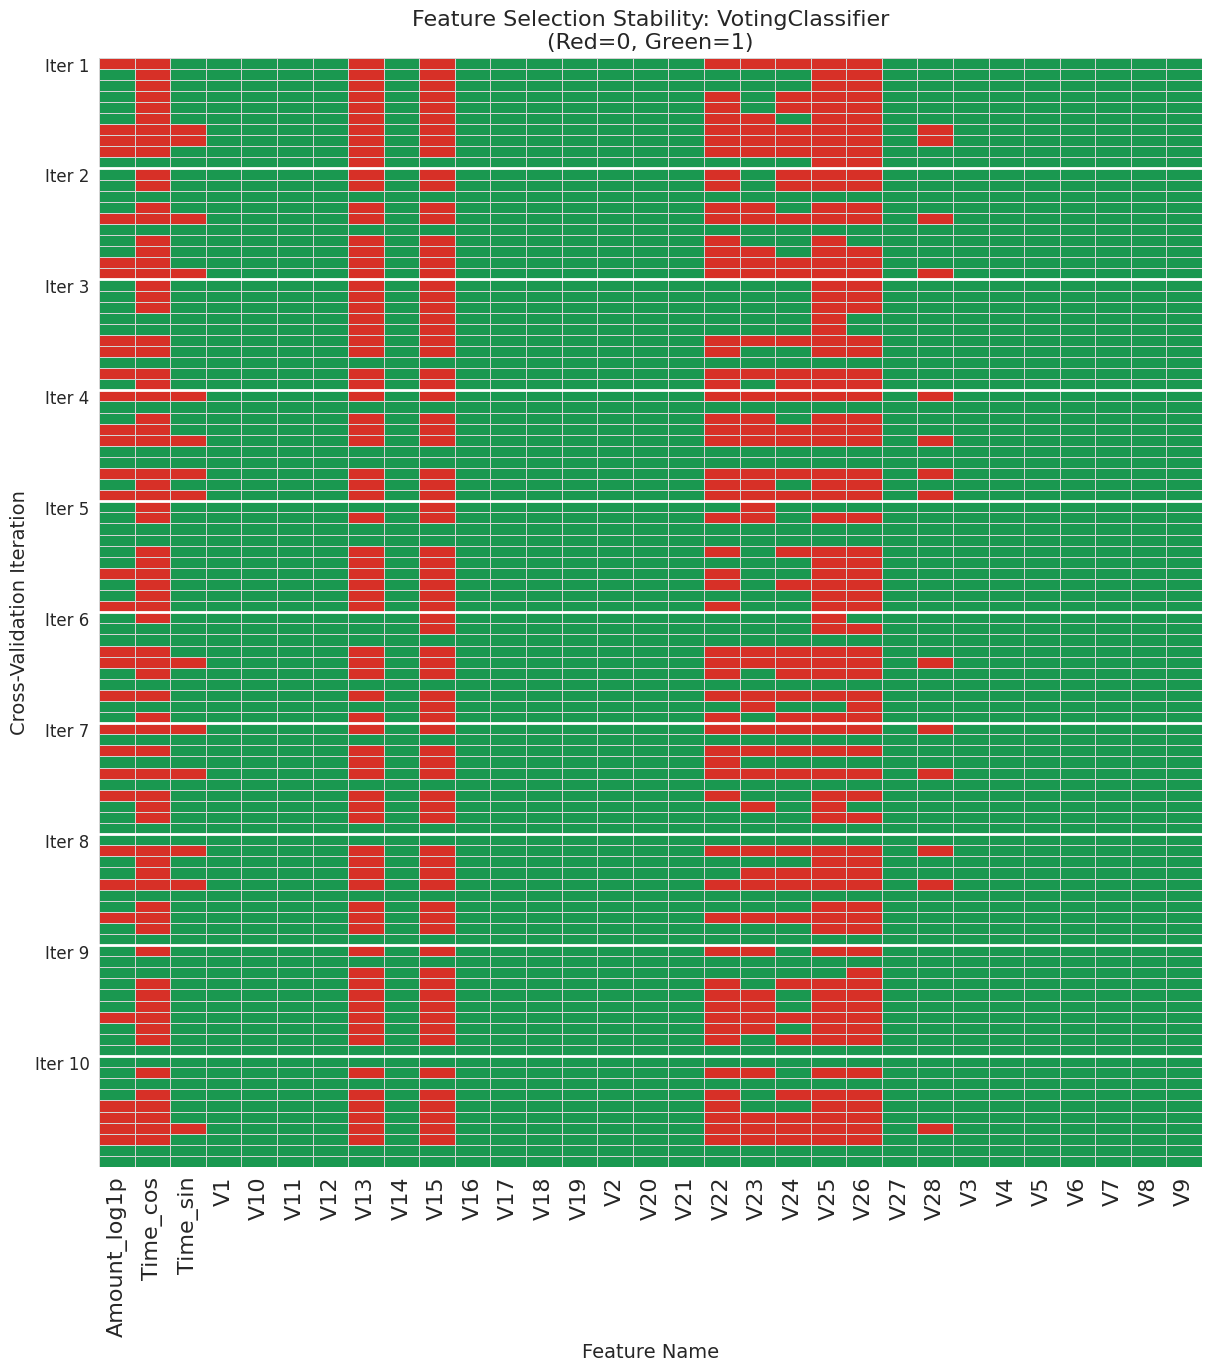

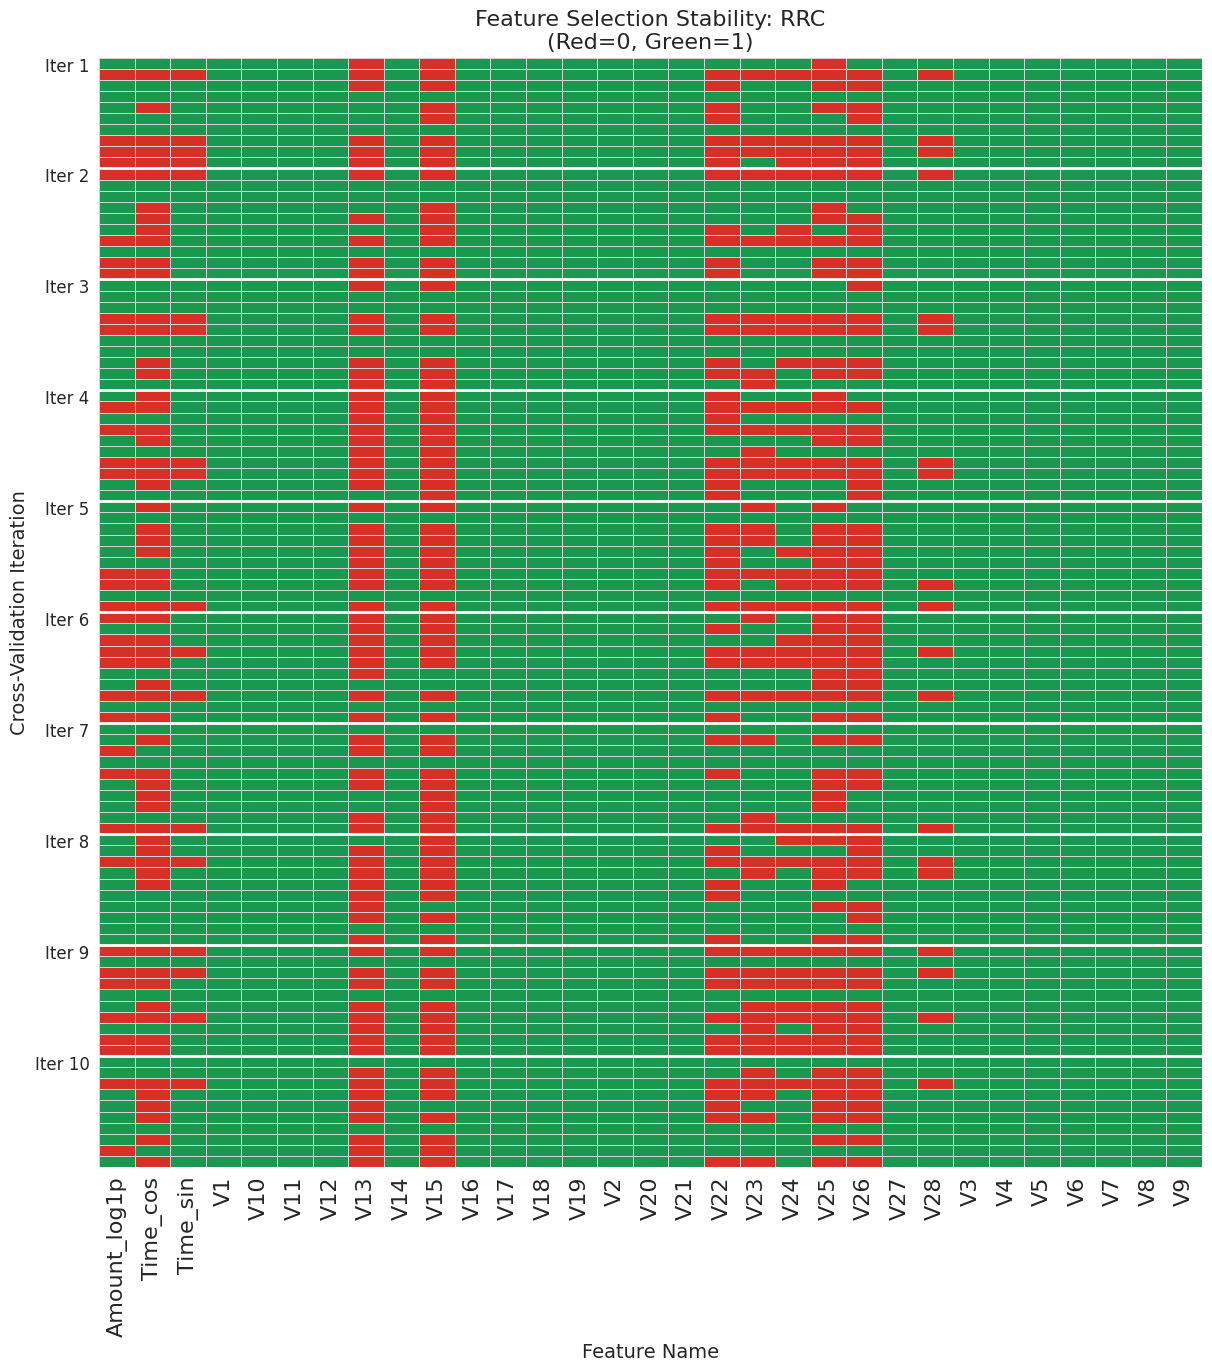

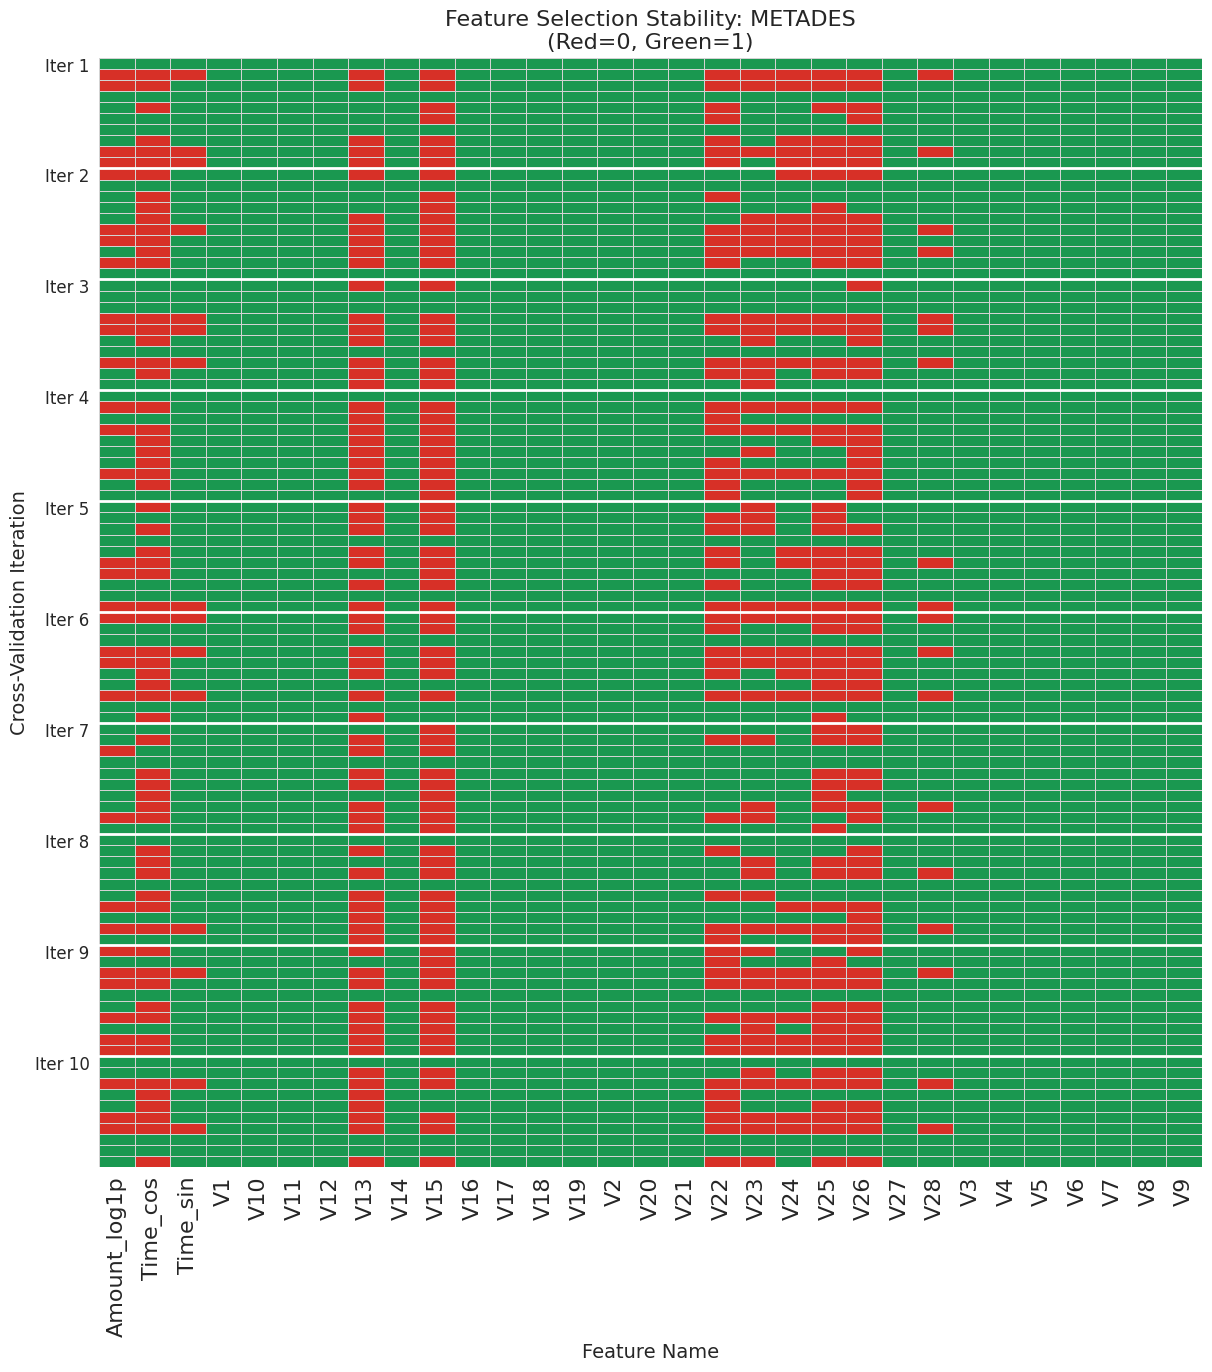

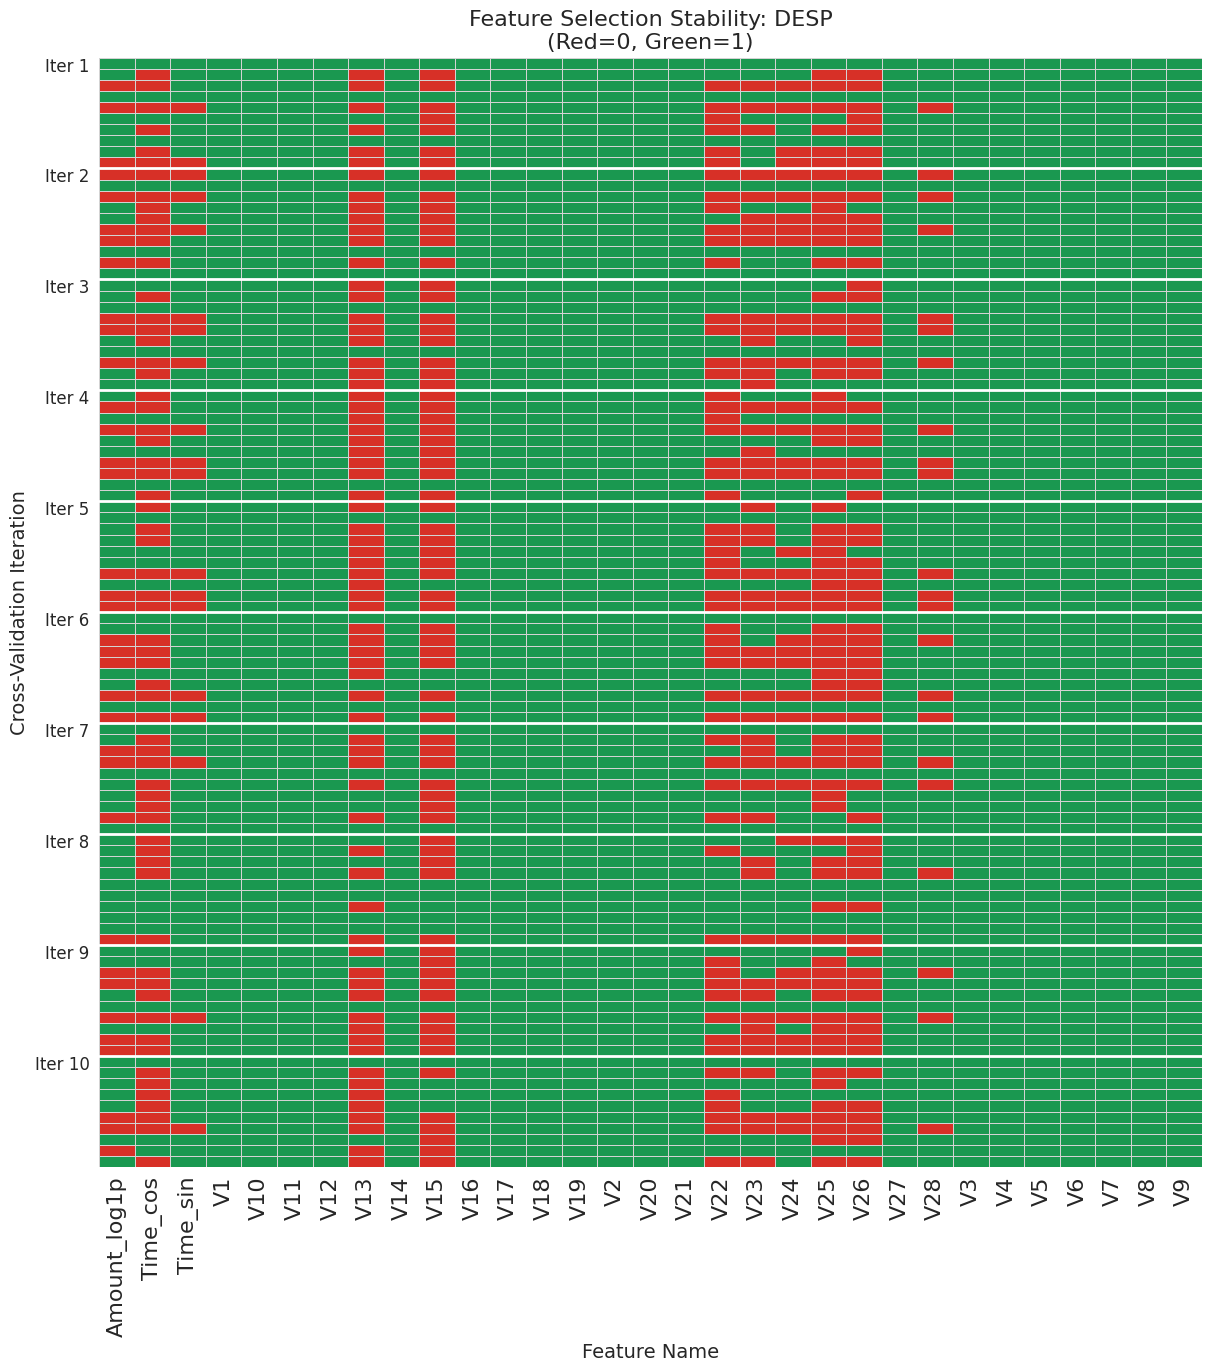

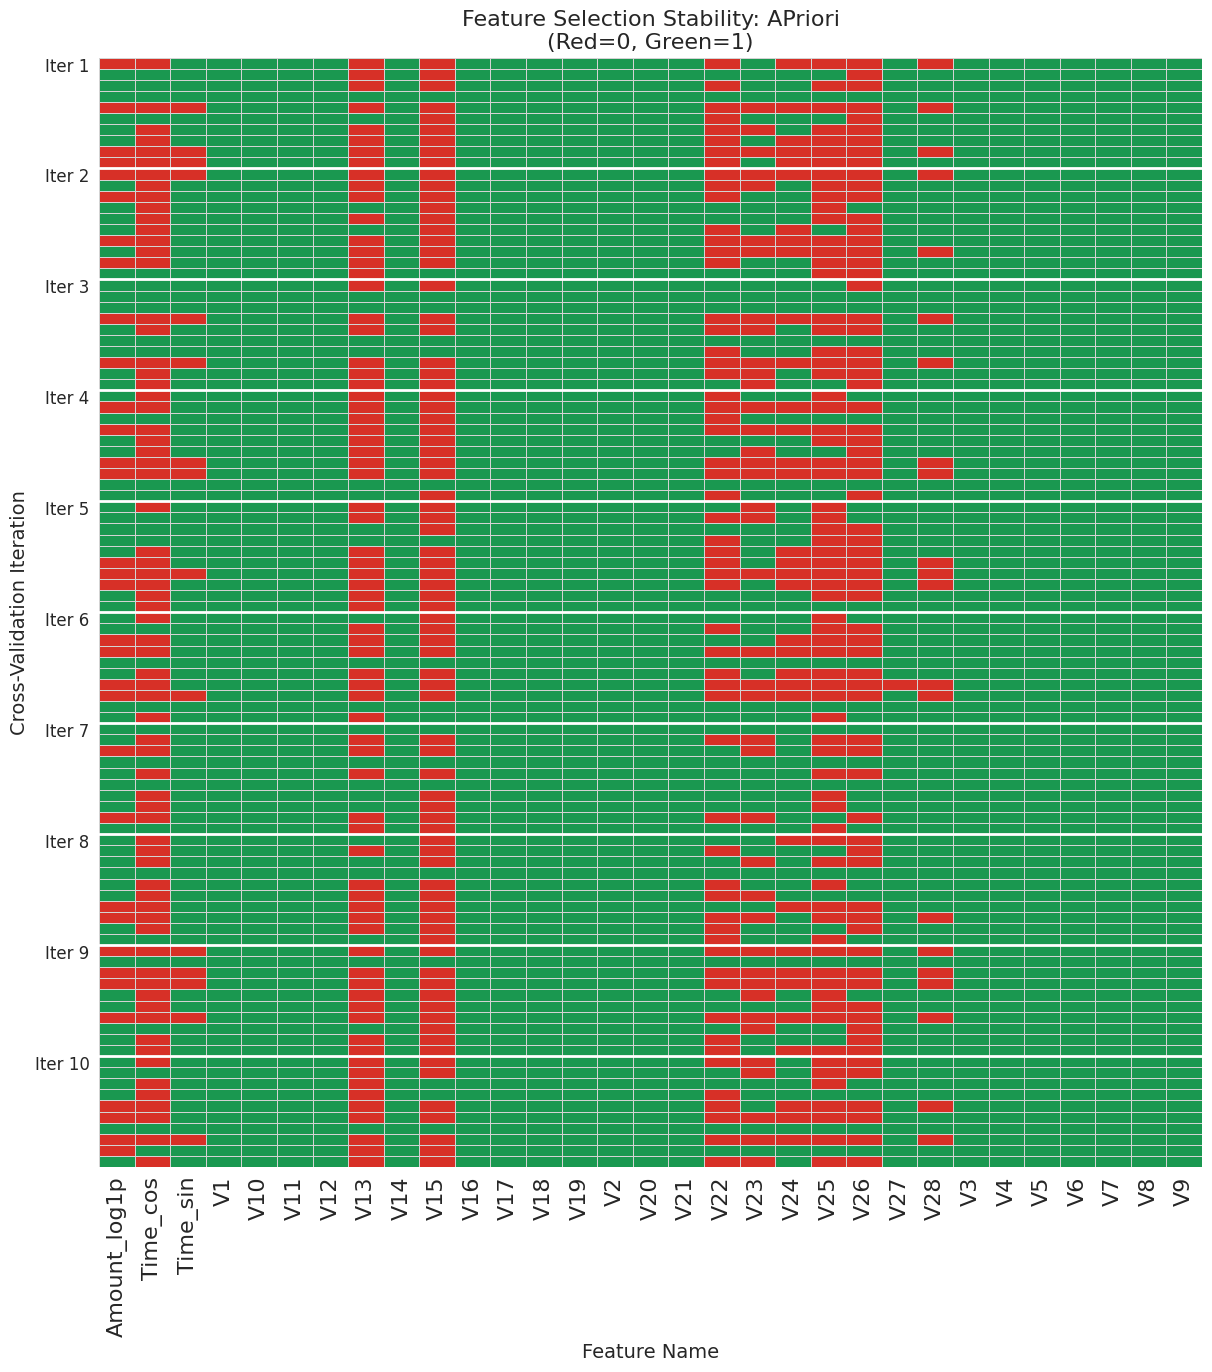

In [14]:
# Prepare Data
red_green_cmap = ListedColormap(["#d73027", "#1a9850"])
unique_models = final_df["model"].unique()

for model in unique_models:
    # Filter & Sort
    model_data = final_df[final_df["model"] == model].copy()
    model_data = model_data.sort_values(["iteration", "fold"])

    # Reset index and CREATE AN EXPLICIT 'ROW_ID' COLUMN
    model_data = model_data.reset_index(drop=True)
    model_data["row_id"] = model_data.index

    # Explode
    exploded = model_data.explode("selected_features_names")
    exploded["is_selected"] = 1

    # Pivot using the 'row_id' column
    matrix = exploded.pivot(
        index="row_id",
        columns="selected_features_names",
        values="is_selected"
    )

    # Cleanup (Fill NaNs, ensure all 100 rows exist)
    matrix = matrix.fillna(0)
    matrix = matrix.reindex(range(100), fill_value=0) # Ensure 0-99 rows exist
    matrix = matrix.sort_index(axis=1)

    # Plotting
    fig_width = max(10, len(matrix.columns) * 0.4)
    fig_height = 14

    plt.figure(figsize=(fig_width, fig_height))

    sns.heatmap(
        matrix,
        cmap=red_green_cmap,
        cbar=False,
        linewidths=0.5,
        linecolor="lightgrey",
        yticklabels=False
    )

    # Custom Y-Ticks to mark the start of each Iteration (Every 10 rows)
    yticks_locs = [i for i in range(0, 100, 10)]
    ytick_labels = [f"Iter {i//10 + 1}" for i in range(0, 100, 10)]

    plt.yticks(
        ticks=yticks_locs,
        labels=ytick_labels,
        rotation=0,
        fontsize=12,
        va="top"
    )

    plt.title(f"Feature Selection Stability: {model}\n(Red=0, Green=1)", fontsize=16)
    plt.xlabel("Feature Name", fontsize=14)
    plt.ylabel("Cross-Validation Iteration", fontsize=14)
    plt.xticks(rotation=90, ha="center")

    # Add horizontal lines to separate Iterations visually
    for i in range(10, 100, 10):
        plt.axhline(i, color="white", linewidth=2)

    plt.tight_layout()
    output_path = FIGURES_FEATURE_SELECTION_EXPERIMENT_DIR / f"features_selected_fingerprint_{model}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()